In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd


,userID,itemID,Rating,Timestamp
0,0,0,5,978300760
1,0,1,3,978302109
2,0,2,3,978301968
3,0,3,4,978300275
4,0,4,5,978824291
...,...,...,...,...
999606,6039,772,1,956716541
999607,6039,1106,5,956704887
999608,6039,365,5,956704746
999609,6039,152,4,956715648


In [19]:

movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))

users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)

(6040, 2)
(3416, 18)


In [20]:
dataset = rating_data
unique_genres.__len__()

18

In [21]:

movies = movies.sort_values(by="itemID")
movies

,movieID,genres,itemID,Action,Thriller,Romance,Western,Children's,Mystery,Fantasy,...,Documentary,Comedy,Adventure,Sci-Fi,Horror,Crime,Musical,War,Animation,Drama
0,1193,Drama,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,661,Animation|Children's|Musical,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
2,914,Musical|Romance,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,3408,Drama,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2355,Animation|Children's|Comedy,4,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,2833,Romance|War,3411,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3412,3207,Adventure,3412,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3413,3533,Drama,3413,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3414,2777,Drama,3414,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [23]:
users
user_features_numpy[:,1]

array([   0,    1,    2, ..., 6037, 6038, 6039])

In [11]:
# inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
# inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
# inter_movies
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data
unique_genres.__len__()

18

In [25]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)


models = []

alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
# alpha_values =[0]
for i in range(len(alpha_values)):
    # learning
    models.append(
        MF(
            k=20,
            seed=123,
            name=f"a={alpha_values[i]} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=1024,
            alpha=alpha_values[i],
            learning_rate=0.002,
            top_k=50, max_iter=19,
            early_stopping=True
        )
    )



# models = [model_1, model_2, model_3, model_4, model_5]
cornac.Experiment(
    ratio_split, models=[models[0]], metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map, f1]
).run()


# Early stopping:
# - best epoch = 16, stopped epoch = 26
# - best monitored value = 0.376458 (delta = -0.010604)

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 6039, 6039, 6039]), array([   0,    1,    2, ..., 2136, 1874,  734]), array([4., 5., 4., ..., 4., 5., 4.]))
Number of users = 6040
Number of items = 3415
Number of ratings = 694578
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50),

 36%|███▌      | 18/50 [00:37<01:07,  2.10s/it, loss=0.538]


Early stopping:
- best epoch = 9, stopped epoch = 19
- best monitored value = 0.377815 (delta = -0.004967)

[a=0 mf] Evaluation started!


Ranking: 100%|██████████| 6040/6040 [00:05<00:00, 1207.05it/s]


VALIDATION:
...
       |   RMSE |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
------ + ------ + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=0 mf | 0.8657 | 0.6426 | 0.0332 |      0.5325 | 0.0268 | 0.1186 |  0.0605 |       0.0251 |    0.0903 |   5.9744

TEST:
...
       |   RMSE |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------ + ------ + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf | 0.8820 | 0.6434 | 0.0529 |      0.6644 | 0.0423 | 0.2046 |  0.0883 |       0.0514 |    0.0913 |   37.8694 |   7.0931



In [17]:
a=0 mf    | 1.0028 | 0.5636 | 0.0528 |      0.6501 | 0.0440 | 0.1571 |  0.0792 |       0.0429 |    0.1009 |    7.9666 |   0.7175

SyntaxError: invalid syntax (395158775.py, line 1)

In [62]:
reco_matrix[0][0].shape

(50,)

In [ ]:
# ratio_split = StratifiedSplit(
#     data=dataset,
#     test_size=0.2,
#     rating_threshold=0.0,
#     seed=123,
#     verbose=True,
#     chrono=True,
#     user_features=user_features_numpy[:, 0],
#     item_features=item_features_numpy,
#     exclude_unknowns=False,
# )
# rec_50 = cornac.metrics.Recall(k=50)
# ndcg_50 = cornac.metrics.NDCG(k=50)
# auc = cornac.metrics.AUC()
# rmse = cornac.metrics.RMSE()
# prec = cornac.metrics.Precision(k=50)
# hr = cornac.metrics.HitRatio(k=50)
# mrr = cornac.metrics.MRR()
# map = cornac.metrics.MAP()


# models = []
# # alpha_values = [0, 0.1,1,10]

# alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
# # alpha_values = [10000,0]
# # alpha_values =[0,0.5]
# # alpha_values = [0,10,50,100, 500,1000,1500, 2000 , 2500, 3000, 4000, 5000, 5500, 60000, 7000, 7500, 8000, 9000, 10000, 200000 ]
# # alpha_values = [0, 0.5,0.8,1]
# # alpha_values =[0,0.8]

# # lr_values = [0.01]
# # alpha_values = [ 0,  0.1,    1,     10,   100,    500,    750,     1000,    2000,   3000,    5000, 7500, 10000]
# # alpha_values = [0,   0.1]
# # lr_values =    [0.0005, 0.0009, 0.0007, 0.0007, 0.0006, 0.0005, 0.0004, 0.0003, 0.0002, 0.0001, 0.00005, 0.00003, 0.00001]
# alpha_values=[0.5]

# #kheyarocks
# for i in range(len(alpha_values)):
#     # learning
#     models.append(
#         MF(
#             k=20,
#             seed=123,
#             name=f"a={alpha_values[i]} mf",
#             backend="pytorch",
#             verbose=True,
#             optimizer="adam",
#             alpha=alpha_values[i],
#             learning_rate=0.001,
#             top_k=50, max_iter=100
#         )
#     )
# # models.append(MF(
# #     k=20,
# #     seed=123,
# #     name=f"a={0} mf",
# #     backend="pytorch",
# #     verbose=True,
# #     optimizer="adam",
# #     alpha=0,top_k=50,
# #     learning_rate=0.01,
# # ))
# # models.append(MF(
# #     k=20,
# #     seed=123,
# #     name=f"a={0.4} mf",
# #     backend="pytorch",
# #     verbose=True,
# #     optimizer="adam",top_k=50,
# #     alpha=0.4,
# #     learning_rate=0.1,
# # ))


# # models = [model_1, model_2, model_3, model_4, model_5]
# cornac.Experiment(
#     ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
# ).run()

In [ ]:

         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN  | 1.0023 | 0.5773 |      0.4867 | 0.0294 | 0.0456 |  0.0351 |       0.0218 |    0.0572 |    0.0742 |   3.1693
ItemKNN  | 1.0739 | 0.5647 |      0.5313 | 0.0329 | 0.0959 |  0.0494 |       0.0305 |    0.0642 |    0.0612 |   5.3363
a=0 mf   | 0.9496 | 0.5751 |      0.6638 | 0.0519 | 0.1983 |  0.0942 |       0.0462 |    0.1156 |    4.3573 |   0.5389
VAECF    | 2.6672 | 0.8691 |      0.9311 | 0.1467 | 0.3588 |  0.2573 |       0.1112 |    0.3596 |    3.6728 |   3.1234
LightGCN | 1.6708 | 0.8673 |      0.9618 | 0.1465 | 0.3733 |  0.2656 |       0.1147 |    0.3749 | 3230.6329 |   3.0017

         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 0.9628 | 0.5767 |      0.6469 | 0.0500 | 0.1838 |  0.0900 |       0.0450 |    0.1131 |    3.5250 |   0.6284
a=0.1 mf | 0.9628 | 0.5767 |      0.6469 | 0.0500 | 0.1838 |  0.0900 |       0.0450 |    0.1131 |   70.9888 |   0.5644

SyntaxError: invalid syntax (812065790.py, line 1)

In [ ]:
from scipy.stats import loguniform

# Define the range for the hyperparameter
low, high = 0, 1

# Create the log-uniform distribution
distribution = loguniform(low, high)

# Sample a single value
sampled_value = distribution.rvs()
print(f'Sampled value: {sampled_value}')

# Sample multiple values
samples = distribution.rvs(size=10)
print(f'Sampled values: {samples}')


In [ ]:
          |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
---------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf     | 1.0002 | 0.5638 |      0.6543 | 0.0431 | 0.1570 |  0.0784 |       0.0422 |    0.1029 |    3.4626 |   0.6022
a=0.1 mf   | 0.9956 | 0.5621 |      0.6458 | 0.0444 | 0.1621 |  0.0803 |       0.0419 |    0.1042 |   18.6450 |   0.5816
a=1 mf     | 0.9881 | 0.5628 |      0.6469 | 0.0458 | 0.1712 |  0.0833 |       0.0428 |    0.1062 |   18.5143 |   0.5465
a=10 mf    | 0.9758 | 0.5653 |      0.6554 | 0.0469 | 0.1765 |  0.0856 |       0.0438 |    0.1083 |   18.5800 |   0.6016
a=100 mf   | 0.9500 | 0.5746 |      0.6501 | 0.0507 | 0.1819 |  0.0916 |       0.0460 |    0.1179 |   18.5632 |   0.5258
a=500 mf   | 0.9528 | 0.5727 |      0.6543 | 0.0506 | 0.1761 |  0.0913 |       0.0458 |    0.1192 |   18.6153 |   0.5430
a=750 mf   | 0.9577 | 0.5693 |      0.6458 | 0.0504 | 0.1733 |  0.0901 |       0.0450 |    0.1178 |   18.7048 |   0.5380
a=1000 mf  | 0.9665 | 0.5632 |      0.6373 | 0.0507 | 0.1702 |  0.0904 |       0.0448 |    0.1191 |   18.8632 |   0.5448
a=2000 mf  | 0.9850 | 0.5517 |      0.6331 | 0.0522 | 0.1743 |  0.0938 |       0.0459 |    0.1224 |   19.1318 |   0.5703
a=3000 mf  | 1.0351 | 0.5337 |      0.6098 | 0.0569 | 0.1992 |  0.1026 |       0.0488 |    0.1275 |   83.5348 |   0.5205
a=5000 mf  | 1.0860 | 0.5297 |      0.6161 | 0.0598 | 0.2114 |  0.1087 |       0.0515 |    0.1336 |   17.8236 |   0.5207
a=7500 mf  | 1.1056 | 0.5284 |      0.6182 | 0.0602 | 0.2206 |  0.1094 |       0.0513 |    0.1325 |  238.7110 |   0.5321
a=10000 mf | 1.1213 | 0.5270 |      0.6214 | 0.0600 | 0.2244 |  0.1096 |       0.0513 |    0.1324 |   18.4401 |   0.5716

In [ ]:
# # choose movies that are only available in the biased subset
# unique_iids = rating_data_pd['itemID'].unique()
# unique_uids = rating_data_pd['userID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
# users = users[users["userID"].isin(unique_uids)]
# #
# users
# # cols_to_select = unique_genres +["itemID", "genres"]
# # new_movies = new_movies[cols_to_select]
# user_ids
         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 1.1047 | 0.5168 |      0.6426 | 0.0643 | 0.2445 |  0.1190 |       0.0557 |    0.1436 |   11.7335 |   1.5513
a=0.5 mf | 1.1155 | 0.5197 |      0.6394 | 0.0642 | 0.2455 |  0.1188 |       0.0557 |    0.1422 |   82.1896 |   0.7491

0.0001
         |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 1.1063 | 0.5107 |      0.6437 | 0.0645 | 0.2473 |  0.1196 |       0.0561 |    0.1436 |    5.6761 |   0.7831
a=0.5 mf | 1.1157 | 0.5103 |      0.6458 | 0.0650 | 0.2468 |  0.1212 |       0.0572 |    0.1462 |   70.2415 |   0.7315


In [36]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
item_ids.__len__()

1349

In [ ]:
# # get the top_k ratings for all users:
# top_k = 20
# reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)
# reco_matrix_all_scores = np.zeros((len(user_ids), len(item_ids)), dtype=int)
# reco_matrix_all_items = np.zeros((len(user_ids), len(item_ids)), dtype=int)

# for i in range(len(user_ids)):
#     reco_items, all_scores = models[0].rank(user_idx=user_ids[i], item_indices=list(item_ids))
#     reco_matrix[i] = reco_items[:top_k]
#     reco_matrix_all_scores[i] = all_scores
#     reco_matrix_all_items[i] = reco_items

In [ ]:
# reco_matrix_reco = np.zeros((len(user_ids),top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_reco[i] = models[0].recommend(user_ids[i])[:top_k]

In [ ]:
# reco_matrix_new = np.zeros((len(user_ids), top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_new[i] = reco_matrix_reco[i][:top_k]

# reco_matrix_new
reco_matrix[0][3]

In [ ]:
reco_matrix[0][69]

In [2]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

NameError: name 'np' is not defined

In [ ]:
reco_matrix[0][2]

In [ ]:
reco_matrix[7][2]


In [63]:
np.save("reco_matrix.npy", reco_matrix)
np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [ ]:
##finding the scores and then re-arranging them in order
item_mappings = OrderedDict(
    [
        (669, 0),
        (128, 1),
        (323, 2),
        (41, 3),
        (1092, 4),
        (2739, 5),
        (1615, 6),
        (2509, 7),
        (1551, 8),
        (1234, 9),
        (346, 10),
        (420, 11),
        (9, 12),
        (3344, 13),
        (23, 14),
        (2463, 15),
        (167, 16),
        (559, 17),
        (3018, 18),
        (2576, 19),
        (104, 20),
        (51, 21),
        (134, 22),
        (1948, 23),
        (309, 24),
        (48, 25),
        (417, 26),
        (381, 27),
        (38, 28),
        (795, 29),
        (43, 30),
        (246, 31),
        (2504, 32),
        (520, 33),
        (225, 34),
        (39, 35),
        (2506, 36),
        (365, 37),
        (109, 38),
        (55, 39),
        (271, 40),
        (1976, 41),
        (229, 42),
        (529, 43),
        (505, 44),
        (141, 45),
        (958, 46),
        (986, 47),
        (280, 48),
        (1106, 49),
        (259, 50),
        (1276, 51),
        (276, 52),
        (361, 53),
        (439, 54),
        (97, 55),
        (336, 56),
        (453, 57),
        (291, 58),
        (1163, 59),
        (95, 60),
        (922, 61),
        (1970, 62),
        (382, 63),
        (176, 64),
        (1235, 65),
        (105, 66),
        (1545, 67),
        (743, 68),
        (1098, 69),
        (1911, 70),
        (2498, 71),
        (2568, 72),
        (2698, 73),
        (1348, 74),
        (71, 75),
        (87, 76),
        (411, 77),
        (1297, 78),
        (1586, 79),
        (217, 80),
        (84, 81),
        (1584, 82),
        (124, 83),
        (127, 84),
        (1241, 85),
        (1915, 86),
        (1298, 87),
        (210, 88),
        (54, 89),
        (1109, 90),
        (797, 91),
        (547, 92),
        (177, 93),
        (147, 94),
        (2893, 95),
        (950, 96),
        (1247, 97),
        (42, 98),
        (1812, 99),
        (15, 100),
        (26, 101),
        (392, 102),
        (1070, 103),
        (714, 104),
        (625, 105),
        (1344, 106),
        (1079, 107),
        (183, 108),
        (152, 109),
        (279, 110),
        (794, 111),
        (218, 112),
        (108, 113),
        (643, 114),
        (847, 115),
        (720, 116),
        (64, 117),
        (646, 118),
        (273, 119),
        (1185, 120),
        (52, 121),
        (1005, 122),
        (1319, 123),
        (799, 124),
        (1270, 125),
        (1959, 126),
        (1992, 127),
        (1111, 128),
        (100, 129),
        (1931, 130),
        (198, 131),
        (1308, 132),
        (186, 133),
        (1543, 134),
        (1049, 135),
        (2737, 136),
        (1303, 137),
        (277, 138),
        (587, 139),
        (676, 140),
        (755, 141),
        (1313, 142),
        (142, 143),
        (424, 144),
        (737, 145),
        (1433, 146),
        (1019, 147),
        (278, 148),
        (2417, 149),
        (635, 150),
        (2859, 151),
        (941, 152),
        (2624, 153),
        (1018, 154),
        (404, 155),
        (399, 156),
        (1176, 157),
        (1217, 158),
        (715, 159),
        (1997, 160),
        (840, 161),
        (1156, 162),
        (777, 163),
        (1340, 164),
        (857, 165),
        (754, 166),
        (604, 167),
        (131, 168),
        (2937, 169),
        (1218, 170),
        (735, 171),
        (1722, 172),
        (1141, 173),
        (1133, 174),
        (1274, 175),
        (1275, 176),
        (1178, 177),
        (1714, 178),
        (1604, 179),
        (2662, 180),
        (1257, 181),
        (772, 182),
        (1072, 183),
        (1081, 184),
        (2025, 185),
        (2029, 186),
        (661, 187),
        (2008, 188),
        (708, 189),
        (1231, 190),
        (629, 191),
        (338, 192),
        (2030, 193),
        (44, 194),
        (2177, 195),
        (2665, 196),
        (0, 197),
        (611, 198),
        (321, 199),
        (1457, 200),
        (174, 201),
        (1195, 202),
        (766, 203),
        (486, 204),
        (2475, 205),
        (1466, 206),
        (696, 207),
        (560, 208),
        (597, 209),
        (998, 210),
        (1517, 211),
        (2302, 212),
        (67, 213),
        (1158, 214),
        (681, 215),
        (2309, 216),
        (2027, 217),
        (206, 218),
        (315, 219),
        (236, 220),
        (633, 221),
        (244, 222),
        (275, 223),
        (1730, 224),
        (1605, 225),
        (1900, 226),
        (1253, 227),
        (2806, 228),
        (2028, 229),
        (162, 230),
        (156, 231),
        (2792, 232),
        (662, 233),
        (1651, 234),
        (383, 235),
        (21, 236),
        (306, 237),
        (1451, 238),
        (101, 239),
        (716, 240),
        (504, 241),
        (553, 242),
        (756, 243),
        (40, 244),
        (153, 245),
        (976, 246),
        (1126, 247),
        (96, 248),
        (861, 249),
        (600, 250),
        (964, 251),
        (1463, 252),
        (648, 253),
        (2032, 254),
        (1292, 255),
        (726, 256),
        (284, 257),
        (994, 258),
        (184, 259),
        (61, 260),
        (1532, 261),
        (1488, 262),
        (135, 263),
        (1456, 264),
        (209, 265),
        (1588, 266),
        (2364, 267),
        (342, 268),
        (1529, 269),
        (1542, 270),
        (121, 271),
        (513, 272),
        (115, 273),
        (1494, 274),
        (1452, 275),
        (1509, 276),
        (3004, 277),
        (175, 278),
        (7, 279),
        (585, 280),
        (1454, 281),
        (170, 282),
        (551, 283),
        (617, 284),
        (45, 285),
        (5, 286),
        (1462, 287),
        (1278, 288),
        (1984, 289),
        (539, 290),
        (1503, 291),
        (2046, 292),
        (1544, 293),
        (2518, 294),
        (733, 295),
        (1194, 296),
        (199, 297),
        (76, 298),
        (22, 299),
        (565, 300),
        (1767, 301),
        (1641, 302),
        (1764, 303),
        (116, 304),
        (798, 305),
        (1260, 306),
        (642, 307),
        (2101, 308),
        (1635, 309),
        (623, 310),
        (851, 311),
        (88, 312),
        (1423, 313),
        (698, 314),
        (645, 315),
        (1495, 316),
        (612, 317),
        (2, 318),
        (1531, 319),
        (2038, 320),
        (1761, 321),
        (649, 322),
        (609, 323),
        (37, 324),
        (33, 325),
        (712, 326),
        (1623, 327),
        (414, 328),
        (2040, 329),
        (390, 330),
        (1045, 331),
        (1860, 332),
        (722, 333),
        (426, 334),
        (1737, 335),
        (1644, 336),
        (1460, 337),
        (632, 338),
        (11, 339),
        (1, 340),
        (419, 341),
        (608, 342),
        (35, 343),
        (1795, 344),
        (2138, 345),
        (421, 346),
        (25, 347),
        (171, 348),
        (213, 349),
        (535, 350),
        (1033, 351),
        (1063, 352),
        (394, 353),
        (3299, 354),
        (1240, 355),
        (444, 356),
        (434, 357),
        (1299, 358),
        (256, 359),
        (1675, 360),
        (47, 361),
        (1447, 362),
        (63, 363),
        (2102, 364),
        (1624, 365),
        (149, 366),
        (829, 367),
        (546, 368),
        (548, 369),
        (2092, 370),
        (159, 371),
        (326, 372),
        (2304, 373),
        (2515, 374),
        (1633, 375),
        (360, 376),
        (665, 377),
        (1619, 378),
        (1042, 379),
        (2145, 380),
        (1960, 381),
        (2031, 382),
        (1394, 383),
        (85, 384),
        (136, 385),
        (1620, 386),
        (428, 387),
        (2705, 388),
        (1564, 389),
        (2152, 390),
        (1064, 391),
        (1465, 392),
        (1639, 393),
        (1450, 394),
        (1232, 395),
        (1491, 396),
        (1261, 397),
        (1582, 398),
        (1561, 399),
        (1555, 400),
        (151, 401),
        (1039, 402),
        (1572, 403),
        (897, 404),
        (1559, 405),
        (1258, 406),
        (1131, 407),
        (242, 408),
        (1118, 409),
        (132, 410),
        (1149, 411),
        (78, 412),
        (120, 413),
        (1552, 414),
        (957, 415),
        (2069, 416),
        (1295, 417),
        (2328, 418),
        (251, 419),
        (523, 420),
        (343, 421),
        (432, 422),
        (264, 423),
        (465, 424),
        (1448, 425),
        (1001, 426),
        (50, 427),
        (770, 428),
        (1501, 429),
        (1621, 430),
        (27, 431),
        (268, 432),
        (568, 433),
        (890, 434),
        (1751, 435),
        (651, 436),
        (1853, 437),
        (862, 438),
        (352, 439),
        (512, 440),
        (788, 441),
        (873, 442),
        (876, 443),
        (3211, 444),
        (927, 445),
        (944, 446),
        (1933, 447),
        (866, 448),
        (790, 449),
        (231, 450),
        (908, 451),
        (515, 452),
        (2211, 453),
        (1993, 454),
        (69, 455),
        (508, 456),
        (1708, 457),
        (932, 458),
        (1558, 459),
        (2137, 460),
        (936, 461),
        (354, 462),
        (1690, 463),
        (363, 464),
        (2151, 465),
        (3, 466),
        (938, 467),
        (327, 468),
        (1614, 469),
        (919, 470),
        (435, 471),
        (1523, 472),
        (454, 473),
        (1305, 474),
        (2155, 475),
        (889, 476),
        (2372, 477),
        (2150, 478),
        (334, 479),
        (219, 480),
        (877, 481),
        (2741, 482),
        (912, 483),
        (524, 484),
        (1135, 485),
        (928, 486),
        (345, 487),
        (943, 488),
        (931, 489),
        (1168, 490),
        (937, 491),
        (2878, 492),
        (860, 493),
        (308, 494),
        (294, 495),
        (94, 496),
        (425, 497),
        (1150, 498),
        (1124, 499),
        (881, 500),
        (974, 501),
        (1387, 502),
        (1159, 503),
        (287, 504),
        (248, 505),
        (800, 506),
        (359, 507),
        (1366, 508),
        (993, 509),
        (3318, 510),
        (311, 511),
        (628, 512),
        (332, 513),
        (250, 514),
        (2156, 515),
        (500, 516),
        (350, 517),
        (263, 518),
        (870, 519),
        (1750, 520),
        (898, 521),
        (1162, 522),
        (243, 523),
        (305, 524),
        (2136, 525),
        (672, 526),
        (445, 527),
        (3091, 528),
        (1097, 529),
        (1916, 530),
        (493, 531),
        (223, 532),
        (929, 533),
        (2430, 534),
        (1925, 535),
        (2671, 536),
        (299, 537),
        (2685, 538),
        (2225, 539),
        (29, 540),
        (262, 541),
        (2844, 542),
        (1496, 543),
        (1522, 544),
        (1920, 545),
        (497, 546),
        (2743, 547),
        (2508, 548),
        (1497, 549),
        (70, 550),
        (1540, 551),
        (2901, 552),
        (1676, 553),
        (1449, 554),
        (1682, 555),
        (2470, 556),
        (3138, 557),
        (834, 558),
        (1520, 559),
        (1618, 560),
        (258, 561),
        (1608, 562),
        (736, 563),
        (961, 564),
        (2692, 565),
        (357, 566),
        (1842, 567),
        (867, 568),
        (1862, 569),
        (2718, 570),
        (3158, 571),
        (589, 572),
        (1483, 573),
        (298, 574),
        (1489, 575),
        (2710, 576),
        (1262, 577),
        (77, 578),
        (1200, 579),
        (2696, 580),
        (2744, 581),
        (2561, 582),
        (2942, 583),
        (351, 584),
        (1822, 585),
        (985, 586),
        (884, 587),
        (1120, 588),
        (2819, 589),
        (3304, 590),
        (143, 591),
        (2222, 592),
        (1115, 593),
        (2258, 594),
        (1612, 595),
        (1514, 596),
        (212, 597),
        (1537, 598),
        (2486, 599),
        (1445, 600),
        (3335, 601),
        (982, 602),
        (415, 603),
        (2011, 604),
        (215, 605),
        (1080, 606),
        (990, 607),
        (1121, 608),
        (372, 609),
        (2438, 610),
        (373, 611),
        (1128, 612),
        (1352, 613),
        (719, 614),
        (1557, 615),
        (2560, 616),
        (1958, 617),
        (283, 618),
        (1843, 619),
        (2106, 620),
        (355, 621),
        (374, 622),
        (2280, 623),
        (2063, 624),
        (748, 625),
        (763, 626),
        (8, 627),
        (2447, 628),
        (376, 629),
        (1008, 630),
        (2466, 631),
        (2562, 632),
        (139, 633),
        (2761, 634),
        (1896, 635),
        (1539, 636),
        (216, 637),
        (1536, 638),
        (1653, 639),
        (615, 640),
        (1566, 641),
        (1405, 642),
        (2188, 643),
        (1755, 644),
        (1845, 645),
        (691, 646),
        (348, 647),
        (1251, 648),
        (506, 649),
        (1646, 650),
        (2099, 651),
        (711, 652),
        (123, 653),
        (377, 654),
        (204, 655),
        (18, 656),
        (639, 657),
        (2602, 658),
        (1210, 659),
        (448, 660),
        (702, 661),
        (379, 662),
        (192, 663),
        (92, 664),
        (650, 665),
        (1047, 666),
        (2687, 667),
        (1574, 668),
        (467, 669),
        (2495, 670),
        (2158, 671),
        (946, 672),
        (1475, 673),
        (728, 674),
        (3213, 675),
        (20, 676),
        (701, 677),
        (81, 678),
        (835, 679),
        (358, 680),
        (495, 681),
        (2423, 682),
        (1492, 683),
        (525, 684),
        (1046, 685),
        (384, 686),
        (3151, 687),
        (594, 688),
        (3343, 689),
        (1583, 690),
        (272, 691),
        (631, 692),
        (1727, 693),
        (1637, 694),
        (165, 695),
        (1499, 696),
        (917, 697),
        (2389, 698),
        (1154, 699),
        (815, 700),
        (301, 701),
        (3044, 702),
        (2392, 703),
        (1962, 704),
        (16, 705),
        (1403, 706),
        (122, 707),
        (2521, 708),
        (479, 709),
        (1648, 710),
        (19, 711),
        (17, 712),
        (1830, 713),
        (316, 714),
        (1096, 715),
        (1130, 716),
        (997, 717),
        (491, 718),
        (514, 719),
        (509, 720),
        (814, 721),
        (331, 722),
        (588, 723),
        (989, 724),
        (129, 725),
        (2035, 726),
        (106, 727),
        (1629, 728),
        (75, 729),
        (2213, 730),
        (4, 731),
        (1951, 732),
        (725, 733),
        (113, 734),
        (140, 735),
        (208, 736),
        (46, 737),
        (1869, 738),
        (34, 739),
        (510, 740),
        (369, 741),
        (324, 742),
        (550, 743),
        (3001, 744),
        (534, 745),
        (1538, 746),
        (1461, 747),
        (684, 748),
        (221, 749),
        (1526, 750),
        (288, 751),
        (168, 752),
        (53, 753),
        (2242, 754),
        (391, 755),
        (255, 756),
        (1570, 757),
        (1913, 758),
        (437, 759),
        (2963, 760),
        (2093, 761),
        (502, 762),
        (2400, 763),
        (740, 764),
        (3015, 765),
        (1666, 766),
        (2283, 767),
        (1528, 768),
        (433, 769),
        (339, 770),
        (498, 771),
        (1966, 772),
        (771, 773),
        (1657, 774),
        (188, 775),
        (337, 776),
        (49, 777),
        (1546, 778),
        (813, 779),
        (803, 780),
        (247, 781),
        (303, 782),
        (2066, 783),
        (823, 784),
        (1649, 785),
        (470, 786),
        (1307, 787),
        (2366, 788),
        (2483, 789),
        (2127, 790),
        (806, 791),
        (1794, 792),
        (90, 793),
        (1594, 794),
        (855, 795),
        (1611, 796),
        (477, 797),
        (1017, 798),
        (1304, 799),
        (110, 800),
        (2527, 801),
        (290, 802),
        (905, 803),
        (586, 804),
        (2870, 805),
        (1470, 806),
        (1099, 807),
        (507, 808),
        (2326, 809),
        (1890, 810),
        (3337, 811),
        (2219, 812),
        (3088, 813),
        (485, 814),
        (1630, 815),
        (1996, 816),
        (62, 817),
        (2254, 818),
        (1706, 819),
        (769, 820),
        (885, 821),
        (459, 822),
        (89, 823),
        (1050, 824),
        (1803, 825),
        (189, 826),
        (1011, 827),
        (269, 828),
        (2834, 829),
        (322, 830),
        (1256, 831),
        (570, 832),
        (314, 833),
        (1577, 834),
        (207, 835),
        (758, 836),
        (1728, 837),
        (2628, 838),
        (499, 839),
        (732, 840),
        (117, 841),
        (1289, 842),
        (2709, 843),
        (527, 844),
        (595, 845),
        (792, 846),
        (1359, 847),
        (2619, 848),
        (1311, 849),
        (584, 850),
        (2745, 851),
        (330, 852),
        (1264, 853),
        (2479, 854),
        (249, 855),
        (709, 856),
        (1858, 857),
        (2147, 858),
        (93, 859),
        (30, 860),
        (848, 861),
        (1004, 862),
        (1236, 863),
        (2097, 864),
        (1051, 865),
        (970, 866),
        (1553, 867),
        (1836, 868),
        (1889, 869),
        (460, 870),
        (1995, 871),
        (580, 872),
        (706, 873),
        (1500, 874),
        (1060, 875),
        (378, 876),
        (265, 877),
        (1301, 878),
        (145, 879),
        (1815, 880),
        (2595, 881),
        (1469, 882),
        (297, 883),
        (713, 884),
        (312, 885),
        (74, 886),
        (980, 887),
        (613, 888),
        (904, 889),
        (2846, 890),
        (446, 891),
        (319, 892),
        (2462, 893),
        (1277, 894),
        (200, 895),
        (2393, 896),
        (1059, 897),
        (727, 898),
        (457, 899),
        (1953, 900),
        (494, 901),
        (2775, 902),
        (1575, 903),
        (1347, 904),
        (320, 905),
        (1273, 906),
        (972, 907),
        (593, 908),
        (724, 909),
        (1393, 910),
        (599, 911),
        (82, 912),
        (723, 913),
        (413, 914),
        (60, 915),
        (538, 916),
        (1014, 917),
        (783, 918),
        (1103, 919),
        (119, 920),
        (2772, 921),
        (1058, 922),
        (155, 923),
        (528, 924),
        (896, 925),
        (619, 926),
        (988, 927),
        (808, 928),
        (762, 929),
        (2493, 930),
        (738, 931),
        (2547, 932),
        (98, 933),
        (86, 934),
        (1664, 935),
        (1190, 936),
        (564, 937),
        (555, 938),
        (1075, 939),
        (1250, 940),
        (1726, 941),
        (954, 942),
        (1326, 943),
        (1723, 944),
        (1057, 945),
        (2164, 946),
        (1189, 947),
        (1719, 948),
        (1029, 949),
        (214, 950),
        (644, 951),
        (767, 952),
        (591, 953),
        (1010, 954),
        (968, 955),
        (558, 956),
        (2013, 957),
        (1242, 958),
        (1940, 959),
        (796, 960),
        (542, 961),
        (164, 962),
        (438, 963),
        (945, 964),
        (1967, 965),
        (2075, 966),
        (226, 967),
        (704, 968),
        (292, 969),
        (1322, 970),
        (450, 971),
        (518, 972),
        (501, 973),
        (1065, 974),
        (2090, 975),
        (484, 976),
        (452, 977),
        (238, 978),
        (371, 979),
        (252, 980),
        (590, 981),
        (114, 982),
        (1672, 983),
        (2406, 984),
        (2734, 985),
        (474, 986),
        (1368, 987),
        (2316, 988),
        (163, 989),
        (1327, 990),
        (1407, 991),
        (482, 992),
        (1408, 993),
        (753, 994),
        (441, 995),
        (3046, 996),
        (511, 997),
        (1906, 998),
        (118, 999),
        (356, 1000),
        (91, 1001),
        (471, 1002),
        (2109, 1003),
        (634, 1004),
        (1401, 1005),
        (703, 1006),
        (1928, 1007),
        (1688, 1008),
        (1385, 1009),
        (2194, 1010),
        (2270, 1011),
        (335, 1012),
        (537, 1013),
        (556, 1014),
        (900, 1015),
        (576, 1016),
        (983, 1017),
        (1181, 1018),
        (396, 1019),
        (521, 1020),
        (1431, 1021),
        (1338, 1022),
        (828, 1023),
        (729, 1024),
        (787, 1025),
        (1395, 1026),
        (667, 1027),
        (638, 1028),
        (1138, 1029),
        (1411, 1030),
        (1334, 1031),
        (627, 1032),
        (686, 1033),
        (1153, 1034),
        (583, 1035),
        (793, 1036),
        (3358, 1037),
        (1370, 1038),
        (657, 1039),
        (1237, 1040),
        (1249, 1041),
        (2227, 1042),
        (1870, 1043),
        (1002, 1044),
        (2039, 1045),
        (891, 1046),
        (1228, 1047),
        (57, 1048),
        (195, 1049),
        (1833, 1050),
        (111, 1051),
        (1090, 1052),
        (845, 1053),
        (3128, 1054),
        (1062, 1055),
        (2123, 1056),
        (1628, 1057),
        (761, 1058),
        (1573, 1059),
        (2321, 1060),
        (1721, 1061),
        (1703, 1062),
        (960, 1063),
        (562, 1064),
        (2263, 1065),
        (1663, 1066),
        (1647, 1067),
        (741, 1068),
        (718, 1069),
        (1371, 1070),
        (137, 1071),
        (2989, 1072),
        (2319, 1073),
        (2200, 1074),
        (1850, 1075),
        (1415, 1076),
        (1691, 1077),
        (2160, 1078),
        (1041, 1079),
        (1384, 1080),
        (468, 1081),
        (1000, 1082),
        (364, 1083),
        (1016, 1084),
        (856, 1085),
        (160, 1086),
        (605, 1087),
        (775, 1088),
        (641, 1089),
        (1259, 1090),
        (864, 1091),
        (630, 1092),
        (2016, 1093),
        (133, 1094),
        (107, 1095),
        (1184, 1096),
        (1209, 1097),
        (1724, 1098),
        (1975, 1099),
        (1095, 1100),
        (1271, 1101),
        (32, 1102),
        (1389, 1103),
        (1397, 1104),
        (695, 1105),
        (2098, 1106),
        (65, 1107),
        (1665, 1108),
        (146, 1109),
        (1192, 1110),
        (1841, 1111),
        (2542, 1112),
        (678, 1113),
        (6, 1114),
        (473, 1115),
        (430, 1116),
        (300, 1117),
        (577, 1118),
        (1712, 1119),
        (79, 1120),
        (843, 1121),
        (1007, 1122),
        (1474, 1123),
        (1003, 1124),
        (603, 1125),
        (984, 1126),
        (1587, 1127),
        (2548, 1128),
        (1119, 1129),
        (1710, 1130),
        (1248, 1131),
        (1680, 1132),
        (194, 1133),
        (915, 1134),
        (880, 1135),
        (966, 1136),
        (1179, 1137),
        (2380, 1138),
        (1923, 1139),
        (1974, 1140),
        (1245, 1141),
        (1808, 1142),
        (2946, 1143),
        (1809, 1144),
        (1810, 1145),
        (2346, 1146),
        (2402, 1147),
        (1807, 1148),
        (1732, 1149),
        (1735, 1150),
        (1739, 1151),
        (3080, 1152),
        (1175, 1153),
        (1505, 1154),
        (1813, 1155),
        (1816, 1156),
        (1734, 1157),
        (2377, 1158),
        (2349, 1159),
        (1679, 1160),
        (1814, 1161),
        (1817, 1162),
        (2376, 1163),
        (909, 1164),
        (2049, 1165),
        (911, 1166),
        (325, 1167),
        (202, 1168),
        (1328, 1169),
        (2253, 1170),
        (760, 1171),
        (1155, 1172),
        (1909, 1173),
        (2638, 1174),
        (2373, 1175),
        (1087, 1176),
        (2646, 1177),
        (910, 1178),
        (914, 1179),
        (1743, 1180),
        (2383, 1181),
        (2637, 1182),
        (1943, 1183),
        (1897, 1184),
        (557, 1185),
        (487, 1186),
        (1790, 1187),
        (2522, 1188),
        (400, 1189),
        (552, 1190),
        (464, 1191),
        (567, 1192),
        (745, 1193),
        (581, 1194),
        (481, 1195),
        (472, 1196),
        (2217, 1197),
        (1365, 1198),
        (1312, 1199),
        (333, 1200),
        (690, 1201),
        (1024, 1202),
        (375, 1203),
        (571, 1204),
        (416, 1205),
        (418, 1206),
        (1386, 1207),
        (2083, 1208),
        (1747, 1209),
        (1745, 1210),
        (1681, 1211),
        (1436, 1212),
        (1364, 1213),
        (1339, 1214),
        (858, 1215),
        (1429, 1216),
        (1333, 1217),
        (1685, 1218),
        (1775, 1219),
        (126, 1220),
        (1442, 1221),
        (1379, 1222),
        (1784, 1223),
        (2104, 1224),
        (1036, 1225),
        (1354, 1226),
        (918, 1227),
        (640, 1228),
        (849, 1229),
        (1749, 1230),
        (1441, 1231),
        (2587, 1232),
        (1404, 1233),
        (1667, 1234),
        (1695, 1235),
        (1848, 1236),
        (1396, 1237),
        (1965, 1238),
        (1918, 1239),
        (1188, 1240),
        (1748, 1241),
        (1430, 1242),
        (1479, 1243),
        (385, 1244),
        (150, 1245),
        (1113, 1246),
        (240, 1247),
        (1689, 1248),
        (148, 1249),
        (1213, 1250),
        (205, 1251),
        (1336, 1252),
        (2167, 1253),
        (125, 1254),
        (895, 1255),
        (58, 1256),
        (166, 1257),
        (1173, 1258),
        (1112, 1259),
        (1482, 1260),
        (2286, 1261),
        (1300, 1262),
        (157, 1263),
        (187, 1264),
        (1439, 1265),
        (66, 1266),
        (193, 1267),
        (1202, 1268),
        (72, 1269),
        (197, 1270),
        (458, 1271),
        (1332, 1272),
        (154, 1273),
        (1381, 1274),
        (1670, 1275),
        (1937, 1276),
        (73, 1277),
        (1715, 1278),
        (1088, 1279),
        (2645, 1280),
        (2313, 1281),
        (2172, 1282),
        (1342, 1283),
        (1102, 1284),
        (2287, 1285),
        (1078, 1286),
        (1655, 1287),
        (1426, 1288),
        (2502, 1289),
        (13, 1290),
        (1331, 1291),
        (730, 1292),
        (2523, 1293),
        (2408, 1294),
        (3272, 1295),
        (1563, 1296),
        (2877, 1297),
        (386, 1298),
        (191, 1299),
        (682, 1300),
        (220, 1301),
        (2294, 1302),
        (995, 1303),
        (1704, 1304),
        (1208, 1305),
        (1084, 1306),
        (463, 1307),
        (1400, 1308),
        (1854, 1309),
        (1212, 1310),
        (2543, 1311),
        (971, 1312),
        (1146, 1313),
        (2260, 1314),
        (185, 1315),
        (1226, 1316),
        (2178, 1317),
        (647, 1318),
        (935, 1319),
        (939, 1320),
        (296, 1321),
        (222, 1322),
        (1481, 1323),
        (1837, 1324),
        (2095, 1325),
        (130, 1326),
        (776, 1327),
        (1198, 1328),
        (1834, 1329),
        (2770, 1330),
        (2925, 1331),
        (1085, 1332),
        (878, 1333),
        (871, 1334),
        (1606, 1335),
        (2170, 1336),
        (1697, 1337),
        (1613, 1338),
        (522, 1339),
        (694, 1340),
        (1693, 1341),
        (679, 1342),
        (1518, 1343),
        (3145, 1344),
        (852, 1345),
        (819, 1346),
        (2755, 1347),
        (1768, 1348),
        (2228, 1349),
        (2119, 1350),
        (610, 1351),
        (1507, 1352),
        (2545, 1353),
        (2861, 1354),
        (83, 1355),
        (196, 1356),
        (1230, 1357),
        (1358, 1358),
        (1382, 1359),
        (1166, 1360),
        (1022, 1361),
        (144, 1362),
        (1562, 1363),
        (1145, 1364),
        (1711, 1365),
        (1125, 1366),
        (1151, 1367),
        (2736, 1368),
        (180, 1369),
        (836, 1370),
        (575, 1371),
        (1797, 1372),
        (1066, 1373),
        (1137, 1374),
        (1074, 1375),
        (3139, 1376),
        (1053, 1377),
        (934, 1378),
        (839, 1379),
        (2036, 1380),
        (2722, 1381),
        (201, 1382),
        (842, 1383),
        (689, 1384),
        (578, 1385),
        (844, 1386),
        (1025, 1387),
        (1478, 1388),
        (675, 1389),
        (656, 1390),
        (2769, 1391),
        (1617, 1392),
        (781, 1393),
        (1417, 1394),
        (10, 1395),
        (671, 1396),
        (739, 1397),
        (673, 1398),
        (1054, 1399),
        (566, 1400),
        (401, 1401),
        (2336, 1402),
        (654, 1403),
        (907, 1404),
        (1091, 1405),
        (3381, 1406),
        (1282, 1407),
        (955, 1408),
        (893, 1409),
        (1272, 1410),
        (2786, 1411),
        (1744, 1412),
        (3045, 1413),
        (489, 1414),
        (1224, 1415),
        (731, 1416),
        (1009, 1417),
        (888, 1418),
        (913, 1419),
        (266, 1420),
        (2307, 1421),
        (1061, 1422),
        (1506, 1423),
        (637, 1424),
        (1512, 1425),
        (865, 1426),
        (2299, 1427),
        (260, 1428),
        (1310, 1429),
        (3085, 1430),
        (607, 1431),
        (1801, 1432),
        (1796, 1433),
        (1357, 1434),
        (1030, 1435),
        (1778, 1436),
        (2374, 1437),
        (2612, 1438),
        (1243, 1439),
        (2086, 1440),
        (1383, 1441),
        (2293, 1442),
        (2478, 1443),
        (579, 1444),
        (2215, 1445),
        (158, 1446),
        (1038, 1447),
        (1374, 1448),
        (412, 1449),
        (2784, 1450),
        (2604, 1451),
        (692, 1452),
        (1355, 1453),
        (274, 1454),
        (1516, 1455),
        (1330, 1456),
        (2421, 1457),
        (825, 1458),
        (1515, 1459),
        (1309, 1460),
        (874, 1461),
        (1786, 1462),
        (1199, 1463),
        (1324, 1464),
        (1783, 1465),
        (1376, 1466),
        (423, 1467),
        (1508, 1468),
        (1926, 1469),
        (2670, 1470),
        (592, 1471),
        (1979, 1472),
        (3121, 1473),
        (1766, 1474),
        (2874, 1475),
        (1598, 1476),
        (2812, 1477),
        (1222, 1478),
        (2503, 1479),
        (699, 1480),
        (734, 1481),
        (1211, 1482),
        (1832, 1483),
        (811, 1484),
        (2888, 1485),
        (2022, 1486),
        (1756, 1487),
        (1266, 1488),
        (1642, 1489),
        (1440, 1490),
        (1083, 1491),
        (1849, 1492),
        (1363, 1493),
        (1856, 1494),
        (2683, 1495),
        (233, 1496),
        (2693, 1497),
        (2005, 1498),
        (2456, 1499),
        (281, 1500),
        (1938, 1501),
        (2517, 1502),
        (2331, 1503),
        (1023, 1504),
        (1645, 1505),
        (462, 1506),
        (693, 1507),
        (2764, 1508),
        (2858, 1509),
        (2300, 1510),
        (234, 1511),
        (2794, 1512),
        (12, 1513),
        (102, 1514),
        (1239, 1515),
        (496, 1516),
        (447, 1517),
        (773, 1518),
        (172, 1519),
        (1654, 1520),
        (2485, 1521),
        (2144, 1522),
        (2558, 1523),
        (228, 1524),
        (765, 1525),
        (36, 1526),
        (1076, 1527),
        (1828, 1528),
        (59, 1529),
        (951, 1530),
        (1283, 1531),
        (2296, 1532),
        (1673, 1533),
        (2244, 1534),
        (2811, 1535),
        (2009, 1536),
        (1772, 1537),
        (2650, 1538),
        (286, 1539),
        (807, 1540),
        (2240, 1541),
        (2924, 1542),
        (31, 1543),
        (14, 1544),
        (926, 1545),
        (1073, 1546),
        (2269, 1547),
        (2471, 1548),
        (2465, 1549),
        (2567, 1550),
        (2131, 1551),
        (1323, 1552),
        (3376, 1553),
        (235, 1554),
        (1792, 1555),
        (541, 1556),
        (68, 1557),
        (2135, 1558),
        (403, 1559),
        (1981, 1560),
        (3274, 1561),
        (824, 1562),
        (1136, 1563),
        (979, 1564),
        (809, 1565),
        (317, 1566),
        (2382, 1567),
        (3093, 1568),
        (626, 1569),
        (683, 1570),
        (1839, 1571),
        (759, 1572),
        (393, 1573),
        (478, 1574),
        (431, 1575),
        (103, 1576),
        (1603, 1577),
        (2000, 1578),
        (2091, 1579),
        (1631, 1580),
        (3209, 1581),
        (179, 1582),
        (1351, 1583),
        (2230, 1584),
        (606, 1585),
        (822, 1586),
        (2831, 1587),
        (1378, 1588),
        (1861, 1589),
        (2674, 1590),
        (1866, 1591),
        (2419, 1592),
        (2425, 1593),
        (1887, 1594),
        (1838, 1595),
        (1267, 1596),
        (1658, 1597),
        (1089, 1598),
        (1028, 1599),
        (569, 1600),
        (2288, 1601),
        (677, 1602),
        (894, 1603),
        (28, 1604),
        (2337, 1605),
        (887, 1606),
        (3171, 1607),
        (2096, 1608),
        (1380, 1609),
        (1343, 1610),
        (1592, 1611),
        (1904, 1612),
        (24, 1613),
        (2448, 1614),
        (1037, 1615),
        (1798, 1616),
        (395, 1617),
        (1788, 1618),
        (1589, 1619),
        (868, 1620),
        (1535, 1621),
        (1134, 1622),
        (2957, 1623),
        (2396, 1624),
        (1142, 1625),
        (1576, 1626),
        (947, 1627),
        (2370, 1628),
        (3079, 1629),
        (1143, 1630),
        (1132, 1631),
        (1114, 1632),
        (1425, 1633),
        (2231, 1634),
        (3290, 1635),
        (2821, 1636),
        (1986, 1637),
        (2347, 1638),
        (1246, 1639),
        (2939, 1640),
        (2010, 1641),
        (2359, 1642),
        (1139, 1643),
        (2391, 1644),
        (1191, 1645),
        (1296, 1646),
        (2956, 1647),
        (1700, 1648),
        (841, 1649),
        (1265, 1650),
        (854, 1651),
        (2969, 1652),
        (1827, 1653),
        (1705, 1654),
        (1972, 1655),
        (1044, 1656),
        (2746, 1657),
        (398, 1658),
        (674, 1659),
        (1686, 1660),
        (2197, 1661),
        (622, 1662),
        (573, 1663),
        (1902, 1664),
        (2847, 1665),
        (2747, 1666),
        (596, 1667),
        (2142, 1668),
        (389, 1669),
        (1973, 1670),
        (1892, 1671),
        (1177, 1672),
        (2180, 1673),
        (717, 1674),
        (1027, 1675),
        (659, 1676),
        (1895, 1677),
        (1182, 1678),
        (366, 1679),
        (353, 1680),
        (1468, 1681),
        (56, 1682),
        (461, 1683),
        (827, 1684),
        (916, 1685),
        (397, 1686),
        (2453, 1687),
        (1687, 1688),
        (920, 1689),
        (1964, 1690),
        (1985, 1691),
        (2520, 1692),
        (2037, 1693),
        (3226, 1694),
        (3041, 1695),
        (2298, 1696),
        (536, 1697),
        (2226, 1698),
        (1467, 1699),
        (2622, 1700),
        (2541, 1701),
        (1446, 1702),
        (2341, 1703),
        (664, 1704),
        (211, 1705),
        (973, 1706),
        (1453, 1707),
        (1472, 1708),
        (1610, 1709),
        (1476, 1710),
        (138, 1711),
        (2043, 1712),
        (2505, 1713),
        (2042, 1714),
        (2528, 1715),
        (2928, 1716),
        (1609, 1717),
        (2489, 1718),
        (1694, 1719),
        (1698, 1720),
        (2112, 1721),
        (2988, 1722),
        (530, 1723),
        (1549, 1724),
        (655, 1725),
        (2414, 1726),
        (2088, 1727),
        (925, 1728),
        (1607, 1729),
        (2394, 1730),
        (1286, 1731),
        (1372, 1732),
        (1216, 1733),
        (821, 1734),
        (2439, 1735),
        (2703, 1736),
        (2882, 1737),
        (2412, 1738),
        (328, 1739),
        (254, 1740),
        (2141, 1741),
        (1950, 1742),
        (1346, 1743),
        (1634, 1744),
        (1662, 1745),
        (1318, 1746),
        (1418, 1747),
        (422, 1748),
        (2277, 1749),
        (688, 1750),
        (2080, 1751),
        (2232, 1752),
        (490, 1753),
        (1471, 1754),
        (1901, 1755),
        (1167, 1756),
        (2530, 1757),
        (2064, 1758),
        (1746, 1759),
        (2699, 1760),
        (2077, 1761),
        (1829, 1762),
        (764, 1763),
        (751, 1764),
        (2162, 1765),
        (2532, 1766),
        (1824, 1767),
        (624, 1768),
        (2367, 1769),
        (1174, 1770),
        (1857, 1771),
        (492, 1772),
        (2529, 1773),
        (2169, 1774),
        (2422, 1775),
        (883, 1776),
        (967, 1777),
        (801, 1778),
        (2814, 1779),
        (1939, 1780),
        (2327, 1781),
        (2690, 1782),
        (598, 1783),
        (1165, 1784),
        (1868, 1785),
        (1392, 1786),
        (1683, 1787),
        (2132, 1788),
        (992, 1789),
        (516, 1790),
        (519, 1791),
        (1263, 1792),
        (340, 1793),
        (406, 1794),
        (831, 1795),
        (2048, 1796),
        (1485, 1797),
        (2237, 1798),
        (1244, 1799),
        (2236, 1800),
        (483, 1801),
        (2484, 1802),
        (2261, 1803),
        (1977, 1804),
        (1661, 1805),
        (475, 1806),
        (978, 1807),
        (2742, 1808),
        (902, 1809),
        (181, 1810),
        (668, 1811),
        (1341, 1812),
        (636, 1813),
        (1458, 1814),
        (1144, 1815),
        (906, 1816),
        (1952, 1817),
        (1660, 1818),
        (921, 1819),
        (1438, 1820),
        (1599, 1821),
        (443, 1822),
        (879, 1823),
        (1912, 1824),
        (757, 1825),
        (1961, 1826),
        (850, 1827),
        (1840, 1828),
        (1360, 1829),
        (1317, 1830),
        (1716, 1831),
        (1410, 1832),
        (886, 1833),
        (1419, 1834),
        (304, 1835),
        (409, 1836),
        (1345, 1837),
        (975, 1838),
        (620, 1839),
        (670, 1840),
        (2218, 1841),
        (680, 1842),
        (2344, 1843),
        (2202, 1844),
        (3188, 1845),
        (1851, 1846),
        (1367, 1847),
        (778, 1848),
        (1108, 1849),
        (2198, 1850),
        (2196, 1851),
        (237, 1852),
        (480, 1853),
        (3022, 1854),
        (1172, 1855),
        (1040, 1856),
        (517, 1857),
        (1229, 1858),
        (1026, 1859),
        (2055, 1860),
        (349, 1861),
        (531, 1862),
        (949, 1863),
        (293, 1864),
        (178, 1865),
        (2206, 1866),
        (872, 1867),
        (1877, 1868),
        (1186, 1869),
        (810, 1870),
        (2360, 1871),
        (3220, 1872),
        (2054, 1873),
        (526, 1874),
        (1284, 1875),
        (779, 1876),
        (368, 1877),
        (267, 1878),
        (1511, 1879),
        (2618, 1880),
        (1288, 1881),
        (875, 1882),
        (3195, 1883),
        (3050, 1884),
        (3086, 1885),
        (2795, 1886),
        (1738, 1887),
        (2571, 1888),
        (2356, 1889),
        (3235, 1890),
        (1760, 1891),
        (2418, 1892),
        (1781, 1893),
        (1388, 1894),
        (1406, 1895),
        (1782, 1896),
        (2998, 1897),
        (2480, 1898),
        (1864, 1899),
        (923, 1900),
        (405, 1901),
        (544, 1902),
        (1846, 1903),
        (1595, 1904),
        (616, 1905),
        (750, 1906),
        (1316, 1907),
        (1874, 1908),
        (1533, 1909),
        (282, 1910),
        (1668, 1911),
        (2500, 1912),
        (285, 1913),
        (1459, 1914),
        (1391, 1915),
        (1898, 1916),
        (2122, 1917),
        (903, 1918),
        (1731, 1919),
        (2608, 1920),
        (1919, 1921),
        (1638, 1922),
        (1513, 1923),
        (2617, 1924),
        (863, 1925),
        (3000, 1926),
        (602, 1927),
        (2212, 1928),
        (2297, 1929),
        (2118, 1930),
        (1534, 1931),
        (832, 1932),
        (1702, 1933),
        (2407, 1934),
        (1701, 1935),
        (469, 1936),
        (2616, 1937),
        (1086, 1938),
        (2146, 1939),
        (2012, 1940),
        (2179, 1941),
        (2068, 1942),
        (3005, 1943),
        (1600, 1944),
        (2256, 1945),
        (3129, 1946),
        (2679, 1947),
        (2676, 1948),
        (2107, 1949),
        (582, 1950),
        (2702, 1951),
        (1082, 1952),
        (488, 1953),
        (1769, 1954),
        (1917, 1955),
        (2533, 1956),
        (2773, 1957),
        (1043, 1958),
        (1093, 1959),
        (2205, 1960),
        (653, 1961),
        (2070, 1962),
        (1034, 1963),
        (2195, 1964),
        (768, 1965),
        (1035, 1966),
        (1314, 1967),
        (2190, 1968),
        (2001, 1969),
        (388, 1970),
        (2853, 1971),
        (2961, 1972),
        (408, 1973),
        (1020, 1974),
        (2322, 1975),
        (2876, 1976),
        (1821, 1977),
        (2667, 1978),
        (2133, 1979),
        (1094, 1980),
        (2124, 1981),
        (956, 1982),
        (2432, 1983),
        (245, 1984),
        (1941, 1985),
        (2808, 1986),
        (660, 1987),
        (2473, 1988),
        (2249, 1989),
        (2611, 1990),
        (1206, 1991),
        (1762, 1992),
        (2248, 1993),
        (239, 1994),
        (2621, 1995),
        (1625, 1996),
        (1464, 1997),
        (2461, 1998),
        (1947, 1999),
        (987, 2000),
        (2607, 2001),
        (2760, 2002),
        (2809, 2003),
        (2161, 2004),
        (2634, 2005),
        (1891, 2006),
        (2259, 2007),
        (427, 2008),
        (1885, 2009),
        (2262, 2010),
        (2534, 2011),
        (563, 2012),
        (747, 2013),
        (742, 2014),
        (601, 2015),
        (1101, 2016),
        (2909, 2017),
        (1593, 2018),
        (1910, 2019),
        (3114, 2020),
        (2458, 2021),
        (1696, 2022),
        (2410, 2023),
        (2730, 2024),
        (1602, 2025),
        (901, 2026),
        (614, 2027),
        (837, 2028),
        (2282, 2029),
        (203, 2030),
        (658, 2031),
        (1863, 2032),
        (1196, 2033),
        (618, 2034),
        (2828, 2035),
        (707, 2036),
        (962, 2037),
        (2332, 2038),
        (1978, 2039),
        (1279, 2040),
        (347, 2041),
        (2848, 2042),
        (2979, 2043),
        (549, 2044),
        (2911, 2045),
        (2713, 2046),
        (3193, 2047),
        (289, 2048),
        (869, 2049),
        (2975, 2050),
        (1107, 2051),
        (3152, 2052),
        (2556, 2053),
        (2664, 2054),
        (1205, 2055),
        (2409, 2056),
        (791, 2057),
        (1884, 2058),
        (1416, 2059),
        (1221, 2060),
        (746, 2061),
        (2902, 2062),
        (744, 2063),
        (2134, 2064),
        (2866, 2065),
        (1315, 2066),
        (1219, 2067),
        (1601, 2068),
        (3264, 2069),
        (2246, 2070),
        (1799, 2071),
        (307, 2072),
        (2201, 2073),
        (826, 2074),
        (2639, 2075),
        (1421, 2076),
        (2017, 2077),
        (3270, 2078),
        (3383, 2079),
        (2404, 2080),
        (1560, 2081),
        (2117, 2082),
        (2052, 2083),
        (3047, 2084),
        (882, 2085),
        (1350, 2086),
        (1859, 2087),
        (2895, 2088),
        (818, 2089),
        (1377, 2090),
        (572, 2091),
        (1335, 2092),
        (2630, 2093),
        (2640, 2094),
        (3164, 2095),
        (933, 2096),
        (402, 2097),
        (2058, 2098),
        (2100, 2099),
        (2652, 2100),
        (1944, 2101),
        (410, 2102),
        (3260, 2103),
        (1757, 2104),
        (1498, 2105),
        (2810, 2106),
        (1398, 2107),
        (3118, 2108),
        (451, 2109),
        (1171, 2110),
        (2125, 2111),
        (1052, 2112),
        (1220, 2113),
        (2181, 2114),
        (2229, 2115),
        (3116, 2116),
        (2175, 2117),
        (476, 2118),
        (440, 2119),
        (2266, 2120),
        (1104, 2121),
        (1811, 2122),
        (3056, 2123),
        (2727, 2124),
        (1930, 2125),
        (2325, 2126),
        (2763, 2127),
        (3057, 2128),
        (1105, 2129),
        (2879, 2130),
        (1835, 2131),
        (2539, 2132),
        (2540, 2133),
        (1291, 2134),
        (1717, 2135),
        (1225, 2136),
        (3053, 2137),
        (774, 2138),
        (1770, 2139),
        (1337, 2140),
        (2872, 2141),
        (2355, 2142),
        (1879, 2143),
        (1519, 2144),
        (996, 2145),
        (1581, 2146),
        (1876, 2147),
        (2014, 2148),
        (2774, 2149),
        (2245, 2150),
        (2538, 2151),
        (2187, 2152),
        (2537, 2153),
        (1547, 2154),
        (2284, 2155),
        (3120, 2156),
        (2255, 2157),
        (1055, 2158),
        (2357, 2159),
        (2233, 2160),
        (2199, 2161),
        (846, 2162),
        (2203, 2163),
        (749, 2164),
        (1021, 2165),
        (2656, 2166),
        (2087, 2167),
        (1752, 2168),
        (2835, 2169),
        (2854, 2170),
        (2677, 2171),
        (1963, 2172),
        (687, 2173),
        (2581, 2174),
        (2460, 2175),
        (1569, 2176),
        (2148, 2177),
        (1999, 2178),
        (1922, 2179),
        (503, 2180),
        (2424, 2181),
        (1320, 2182),
        (442, 2183),
        (2823, 2184),
        (2753, 2185),
        (2303, 2186),
        (1567, 2187),
        (2781, 2188),
        (1942, 2189),
        (2330, 2190),
        (2116, 2191),
        (2510, 2192),
        (2615, 2193),
        (1031, 2194),
        (3052, 2195),
        (2797, 2196),
        (2701, 2197),
        (2544, 2198),
        (621, 2199),
        (1823, 2200),
        (169, 2201),
        (2044, 2202),
        (161, 2203),
        (1568, 2204),
        (1652, 2205),
        (1123, 2206),
        (3360, 2207),
        (965, 2208),
        (953, 2209),
        (969, 2210),
        (963, 2211),
        (2371, 2212),
        (2511, 2213),
        (2954, 2214),
        (2653, 2215),
        (1530, 2216),
        (1117, 2217),
        (2362, 2218),
        (230, 2219),
        (1164, 2220),
        (2762, 2221),
        (2706, 2222),
        (2651, 2223),
        (2952, 2224),
        (3048, 2225),
        (1390, 2226),
        (3311, 2227),
        (3040, 2228),
        (2143, 2229),
        (1287, 2230),
        (817, 2231),
        (1127, 2232),
        (2754, 2233),
        (2413, 2234),
        (930, 2235),
        (2403, 2236),
        (1590, 2237),
        (2130, 2238),
        (3271, 2239),
        (1669, 2240),
        (1659, 2241),
        (2589, 2242),
        (2053, 2243),
        (1650, 2244),
        (2936, 2245),
        (2583, 2246),
        (2717, 2247),
        (380, 2248),
        (1252, 2249),
        (2153, 2250),
        (2803, 2251),
        (2026, 2252),
        (2033, 2253),
        (1899, 2254),
        (2317, 2255),
        (812, 2256),
        (2822, 2257),
        (1302, 2258),
        (3312, 2259),
        (1826, 2260),
        (1420, 2261),
        (2626, 2262),
        (1773, 2263),
        (1435, 2264),
        (2459, 2265),
        (1116, 2266),
        (3359, 2267),
        (3404, 2268),
        (838, 2269),
        (2953, 2270),
        (2590, 2271),
        (2712, 2272),
        (2216, 2273),
        (2600, 2274),
        (2221, 2275),
        (2707, 2276),
        (257, 2277),
        (3076, 2278),
        (2620, 2279),
        (3340, 2280),
        (2536, 2281),
        (329, 2282),
        (2820, 2283),
        (2609, 2284),
        (224, 2285),
        (1677, 2286),
        (182, 2287),
        (2688, 2288),
        (2501, 2289),
        (2605, 2290),
        (2234, 2291),
        (1077, 2292),
        (2631, 2293),
        (1329, 2294),
        (697, 2295),
        (2271, 2296),
        (3413, 2297),
        (2047, 2298),
        (2168, 2299),
        (2084, 2300),
        (1129, 2301),
        (3150, 2302),
        (2824, 2303),
        (1591, 2304),
        (2880, 2305),
        (1434, 2306),
        (1541, 2307),
        (1556, 2308),
        (3353, 2309),
        (3396, 2310),
        (3105, 2311),
        (3303, 2312),
        (3119, 2313),
        (1626, 2314),
        (3181, 2315),
        (3084, 2316),
        (1883, 2317),
        (3037, 2318),
        (540, 2319),
        (344, 2320),
        (1949, 2321),
        (1122, 2322),
        (3135, 2323),
        (2929, 2324),
        (2985, 2325),
        (2945, 2326),
        (2931, 2327),
        (2354, 2328),
        (2614, 2329),
        (2955, 2330),
        (2948, 2331),
        (2384, 2332),
        (2385, 2333),
        (2981, 2334),
        (2351, 2335),
        (1733, 2336),
        (2983, 2337),
        (2557, 2338),
        (1140, 2339),
        (1989, 2340),
        (2015, 2341),
        (3300, 2342),
        (2906, 2343),
        (3258, 2344),
        (1968, 2345),
        (3309, 2346),
        (2943, 2347),
        (2018, 2348),
        (1223, 2349),
        (466, 2350),
        (574, 2351),
        (3313, 2352),
        (2633, 2353),
        (1907, 2354),
        (1882, 2355),
        (2881, 2356),
        (1998, 2357),
        (3276, 2358),
        (2660, 2359),
        (1100, 2360),
        (341, 2361),
        (1793, 2362),
        (3069, 2363),
        (2825, 2364),
        (1443, 2365),
        (2782, 2366),
        (1361, 2367),
        (1183, 2368),
        (830, 2369),
        (2368, 2370),
        (1193, 2371),
        (2401, 2372),
        (2729, 2373),
        (3073, 2374),
        (2930, 2375),
        (2220, 2376),
        (1502, 2377),
        (2324, 2378),
        (899, 2379),
        (2301, 2380),
        (2625, 2381),
        (1929, 2382),
        (3219, 2383),
        (2554, 2384),
        (3140, 2385),
        (2689, 2386),
        (2405, 2387),
        (789, 2388),
        (3286, 2389),
        (3016, 2390),
        (3096, 2391),
        (2569, 2392),
        (2708, 2393),
        (1487, 2394),
        (232, 2395),
        (2034, 2396),
        (2694, 2397),
        (1825, 2398),
        (752, 2399),
        (2176, 2400),
        (2440, 2401),
        (1692, 2402),
        (2454, 2403),
        (1321, 2404),
        (2285, 2405),
        (2796, 2406),
        (2204, 2407),
        (1946, 2408),
        (2563, 2409),
        (816, 2410),
        (2467, 2411),
        (3039, 2412),
        (2933, 2413),
        (1413, 2414),
        (436, 2415),
        (2094, 2416),
        (1402, 2417),
        (2599, 2418),
        (3314, 2419),
        (2886, 2420),
        (2750, 2421),
        (2867, 2422),
        (2871, 2423),
        (1671, 2424),
        (2663, 2425),
        (1932, 2426),
        (313, 2427),
        (2114, 2428),
        (261, 2429),
        (1707, 2430),
        (1373, 2431),
        (1969, 2432),
        (1032, 2433),
        (1903, 2434),
        (1771, 2435),
        (2085, 2436),
        (2606, 2437),
        (1957, 2438),
        (1954, 2439),
        (1306, 2440),
        (2140, 2441),
        (2613, 2442),
        (2474, 2443),
        (2805, 2444),
        (2751, 2445),
        (1207, 2446),
        (1204, 2447),
        (3250, 2448),
        (173, 2449),
        (533, 2450),
        (429, 2451),
        (2912, 2452),
        (1187, 2453),
        (1524, 2454),
        (1157, 2455),
        (532, 2456),
        (2235, 2457),
        (2623, 2458),
        (3332, 2459),
        (2725, 2460),
        (2441, 2461),
        (80, 2462),
        (2959, 2463),
        (2802, 2464),
        (2154, 2465),
        (2171, 2466),
        (1169, 2467),
        (2078, 2468),
        (387, 2469),
        (2855, 2470),
        (3197, 2471),
        (2793, 2472),
        (310, 2473),
        (2073, 2474),
        (2274, 2475),
        (1048, 2476),
        (1934, 2477),
        (561, 2478),
        (1927, 2479),
        (1353, 2480),
        (1412, 2481),
        (1510, 2482),
        (1013, 2483),
        (1268, 2484),
        (2716, 2485),
        (3175, 2486),
        (1349, 2487),
        (2182, 2488),
        (2082, 2489),
        (2594, 2490),
        (2519, 2491),
        (3228, 2492),
        (940, 2493),
        (3159, 2494),
        (1325, 2495),
        (2358, 2496),
        (2635, 2497),
        (1736, 2498),
        (1740, 2499),
        (2340, 2500),
        (2350, 2501),
        (2348, 2502),
        (1893, 2503),
        (1180, 2504),
        (1056, 2505),
        (2051, 2506),
        (2257, 2507),
        (2494, 2508),
        (2869, 2509),
        (3370, 2510),
        (3092, 2511),
        (3010, 2512),
        (2732, 2513),
        (2836, 2514),
        (3330, 2515),
        (2193, 2516),
        (1521, 2517),
        (3392, 2518),
        (3221, 2519),
        (3075, 2520),
        (3191, 2521),
        (455, 2522),
        (2552, 2523),
        (3202, 2524),
        (2584, 2525),
        (3071, 2526),
        (3216, 2527),
        (2980, 2528),
        (1493, 2529),
        (2588, 2530),
        (859, 2531),
        (3368, 2532),
        (2704, 2533),
        (942, 2534),
        (853, 2535),
        (2076, 2536),
        (3186, 2537),
        (820, 2538),
        (1819, 2539),
        (2074, 2540),
        (2972, 2541),
        (3104, 2542),
        (2314, 2543),
        (1285, 2544),
        (2758, 2545),
        (1596, 2546),
        (999, 2547),
        (1753, 2548),
        (543, 2549),
        (2864, 2550),
        (2865, 2551),
        (2748, 2552),
        (2416, 2553),
        (2427, 2554),
        (2311, 2555),
        (2839, 2556),
        (2251, 2557),
        (1852, 2558),
        (1777, 2559),
        (3316, 2560),
        (2668, 2561),
        (2678, 2562),
        (2661, 2563),
        (2361, 2564),
        (2850, 2565),
        (190, 2566),
        (1804, 2567),
        (2399, 2568),
        (3292, 2569),
        (3065, 2570),
        (2857, 2571),
        (1399, 2572),
        (3329, 2573),
        (2184, 2574),
        (2002, 2575),
        (2940, 2576),
        (2111, 2577),
        (2165, 2578),
        (3236, 2579),
        (1233, 2580),
        (1147, 2581),
        (2071, 2582),
        (2339, 2583),
        (2490, 2584),
        (1148, 2585),
        (1254, 2586),
        (2345, 2587),
        (2320, 2588),
        (1597, 2589),
        (2597, 2590),
        (2267, 2591),
        (2268, 2592),
        (3281, 2593),
        (959, 2594),
        (2783, 2595),
        (2434, 2596),
        (1871, 2597),
        (805, 2598),
        (2582, 2599),
        (2343, 2600),
        (1983, 2601),
        (1713, 2602),
        (1955, 2603),
        (1881, 2604),
        (3212, 2605),
        (3083, 2606),
        (2832, 2607),
        (2105, 2608),
        (2596, 2609),
        (1414, 2610),
        (2756, 2611),
        (1791, 2612),
        (1787, 2613),
        (1684, 2614),
        (3262, 2615),
        (1785, 2616),
        (2603, 2617),
        (1571, 2618),
        (3182, 2619),
        (3082, 2620),
        (2415, 2621),
        (112, 2622),
        (663, 2623),
        (2815, 2624),
        (2472, 2625),
        (2921, 2626),
        (3009, 2627),
        (3305, 2628),
        (892, 2629),
        (2863, 2630),
        (652, 2631),
        (1427, 2632),
        (1071, 2633),
        (2591, 2634),
        (2524, 2635),
        (1780, 2636),
        (1269, 2637),
        (2481, 2638),
        (3146, 2639),
        (3352, 2640),
        (3243, 2641),
        (3302, 2642),
        (2719, 2643),
        (2691, 2644),
        (3223, 2645),
        (2682, 2646),
        (3036, 2647),
        (2889, 2648),
        (2994, 2649),
        (2435, 2650),
        (3117, 2651),
        (786, 2652),
        (2890, 2653),
        (2079, 2654),
        (2922, 2655),
        (3180, 2656),
        (2451, 2657),
        (2103, 2658),
        (3111, 2659),
        (2120, 2660),
        (1765, 2661),
        (2968, 2662),
        (2121, 2663),
        (1369, 2664),
        (2728, 2665),
        (1424, 2666),
        (2627, 2667),
        (3275, 2668),
        (3008, 2669),
        (2278, 2670),
        (2186, 2671),
        (1820, 2672),
        (2338, 2673),
        (3143, 2674),
        (3067, 2675),
        (3369, 2676),
        (3095, 2677),
        (2247, 2678),
        (1855, 2679),
        (1980, 2680),
        (1548, 2681),
        (2566, 2682),
        (3254, 2683),
        (2629, 2684),
        (2585, 2685),
        (3238, 2686),
        (705, 2687),
        (2163, 2688),
        (2166, 2689),
        (2641, 2690),
        (2898, 2691),
        (2798, 2692),
        (2643, 2693),
        (2838, 2694),
        (3178, 2695),
        (2852, 2696),
        (3109, 2697),
        (2496, 2698),
        (2856, 2699),
        (1872, 2700),
        (2973, 2701),
        (1152, 2702),
        (1203, 2703),
        (3072, 2704),
        (2813, 2705),
        (2992, 2706),
        (1888, 2707),
        (3035, 2708),
        (2868, 2709),
        (2778, 2710),
        (2452, 2711),
        (2990, 2712),
        (1867, 2713),
        (2826, 2714),
        (2738, 2715),
        (2264, 2716),
        (1729, 2717),
        (1636, 2718),
        (721, 2719),
        (1015, 2720),
        (1290, 2721),
        (1718, 2722),
        (1293, 2723),
        (1565, 2724),
        (1616, 2725),
        (1742, 2726),
        (3020, 2727),
        (2724, 2728),
        (2308, 2729),
        (3354, 2730),
        (2329, 2731),
        (1455, 2732),
        (456, 2733),
        (2572, 2734),
        (2767, 2735),
        (2455, 2736),
        (2564, 2737),
        (3409, 2738),
        (3405, 2739),
        (1886, 2740),
        (1878, 2741),
        (3173, 2742),
        (1971, 2743),
        (1844, 2744),
        (2318, 2745),
        (3266, 2746),
        (2735, 2747),
        (666, 2748),
        (2559, 2749),
        (1068, 2750),
        (2765, 2751),
        (1987, 2752),
        (2081, 2753),
        (1924, 2754),
        (2065, 2755),
        (2759, 2756),
        (802, 2757),
        (2477, 2758),
        (3397, 2759),
        (2720, 2760),
        (3074, 2761),
        (3019, 2762),
        (784, 2763),
        (3232, 2764),
        (1280, 2765),
        (1444, 2766),
        (924, 2767),
        (1847, 2768),
        (2546, 2769),
        (1982, 2770),
        (3347, 2771),
        (981, 2772),
        (3371, 2773),
        (1800, 2774),
        (2057, 2775),
        (2512, 2776),
        (2210, 2777),
        (2275, 2778),
        (295, 2779),
        (2938, 2780),
        (2726, 2781),
        (2681, 2782),
        (1818, 2783),
        (362, 2784),
        (3410, 2785),
        (1656, 2786),
        (1779, 2787),
        (253, 2788),
        (2553, 2789),
        (2843, 2790),
        (1069, 2791),
        (2771, 2792),
        (370, 2793),
        (1894, 2794),
        (785, 2795),
        (1160, 2796),
        (3210, 2797),
        (2632, 2798),
        (2947, 2799),
        (2243, 2800),
        (3032, 2801),
        (1945, 2802),
        (3310, 2803),
        (2723, 2804),
        (2386, 2805),
        (1699, 2806),
        (2289, 2807),
        (270, 2808),
        (3189, 2809),
        (952, 2810),
        (3323, 2811),
        (2273, 2812),
        (2999, 2813),
        (2995, 2814),
        (2644, 2815),
        (2894, 2816),
        (3070, 2817),
        (2513, 2818),
        (2573, 2819),
        (3148, 2820),
        (2265, 2821),
        (2060, 2822),
        (1281, 2823),
        (2115, 2824),
        (2436, 2825),
        (2238, 2826),
        (1789, 2827),
        (1579, 2828),
        (1477, 2829),
        (710, 2830),
        (2113, 2831),
        (3324, 2832),
        (2549, 2833),
        (3325, 2834),
        (3112, 2835),
        (1067, 2836),
        (1578, 2837),
        (407, 2838),
        (1422, 2839),
        (1428, 2840),
        (1674, 2841),
        (2996, 2842),
        (99, 2843),
        (3029, 2844),
        (1988, 2845),
        (2962, 2846),
        (685, 2847),
        (782, 2848),
        (2789, 2849),
        (2601, 2850),
        (2129, 2851),
        (2993, 2852),
        (3291, 2853),
        (3377, 2854),
        (2636, 2855),
        (3014, 2856),
        (3380, 2857),
        (2426, 2858),
        (2697, 2859),
        (2291, 2860),
        (3110, 2861),
        (2598, 2862),
        (2991, 2863),
        (2442, 2864),
        (2986, 2865),
        (3068, 2866),
        (3296, 2867),
        (1880, 2868),
        (3411, 2869),
        (2551, 2870),
        (3415, 2871),
        (2695, 2872),
        (2910, 2873),
        (1255, 2874),
        (1806, 2875),
        (804, 2876),
        (2923, 2877),
        (2648, 2878),
        (2272, 2879),
        (2610, 2880),
        (554, 2881),
        (1831, 2882),
        (2757, 2883),
        (3127, 2884),
        (2673, 2885),
        (3289, 2886),
        (3386, 2887),
        (3373, 2888),
        (2669, 2889),
        (3224, 2890),
        (2061, 2891),
        (3349, 2892),
        (1375, 2893),
        (2189, 2894),
        (545, 2895),
        (3162, 2896),
        (2056, 2897),
        (2214, 2898),
        (3133, 2899),
        (2041, 2900),
        (3240, 2901),
        (2241, 2902),
        (3284, 2903),
        (2208, 2904),
        (3064, 2905),
        (2787, 2906),
        (2904, 2907),
        (2829, 2908),
        (2721, 2909),
        (3049, 2910),
        (3090, 2911),
        (1741, 2912),
        (2908, 2913),
        (2469, 2914),
        (700, 2915),
        (3132, 2916),
        (3007, 2917),
        (2649, 2918),
        (3061, 2919),
        (2428, 2920),
        (2516, 2921),
        (2378, 2922),
        (2397, 2923),
        (3167, 2924),
        (1640, 2925),
        (2913, 2926),
        (1580, 2927),
        (3026, 2928),
        (3066, 2929),
        (2279, 2930),
        (3017, 2931),
        (2970, 2932),
        (1720, 2933),
        (3160, 2934),
        (2531, 2935),
        (3374, 2936),
        (1214, 2937),
        (1215, 2938),
        (2666, 2939),
        (1486, 2940),
        (2892, 2941),
        (2949, 2942),
        (2365, 2943),
        (2680, 2944),
        (1759, 2945),
        (1627, 2946),
        (3403, 2947),
        (1758, 2948),
        (3267, 2949),
        (3265, 2950),
        (2381, 2951),
        (2984, 2952),
        (2840, 2953),
        (3412, 2954),
        (3382, 2955),
        (2431, 2956),
        (2491, 2957),
        (1437, 2958),
        (1643, 2959),
        (2128, 2960),
        (3372, 2961),
        (3268, 2962),
        (2223, 2963),
        (2021, 2964),
        (2252, 2965),
        (1484, 2966),
        (1754, 2967),
        (3215, 2968),
        (2776, 2969),
        (1161, 2970),
        (3137, 2971),
        (2192, 2972),
        (1865, 2973),
        (2191, 2974),
        (2050, 2975),
        (3012, 2976),
        (3351, 2977),
        (1905, 2978),
        (2885, 2979),
        (1197, 2980),
        (3060, 2981),
        (1622, 2982),
        (3097, 2983),
        (2003, 2984),
        (1914, 2985),
        (3261, 2986),
        (3103, 2987),
        (2715, 2988),
        (2323, 2989),
        (2514, 2990),
        (2777, 2991),
        (2335, 2992),
        (1936, 2993),
        (1921, 2994),
        (1875, 2995),
        (449, 2996),
        (977, 2997),
        (3108, 2998),
        (2915, 2999),
        (2062, 3000),
        (2960, 3001),
        (1776, 3002),
        (2731, 3003),
        (3230, 3004),
        (2305, 3005),
        (2089, 3006),
        (2926, 3007),
        (3174, 3008),
        (2907, 3009),
        (3131, 3010),
        (2920, 3011),
        (2967, 3012),
        (2918, 3013),
        (2932, 3014),
        (1294, 3015),
        (3355, 3016),
        (3378, 3017),
        (3249, 3018),
        (3034, 3019),
        (2672, 3020),
        (2905, 3021),
        (3234, 3022),
        (3087, 3023),
        (3248, 3024),
        (2740, 3025),
        (1956, 3026),
        (3217, 3027),
        (2059, 3028),
        (2276, 3029),
        (241, 3030),
        (2398, 3031),
        (2157, 3032),
        (2851, 3033),
        (2487, 3034),
        (1227, 3035),
        (2379, 3036),
        (3144, 3037),
        (2891, 3038),
        (833, 3039),
        (2457, 3040),
        (2445, 3041),
        (2700, 3042),
        (2965, 3043),
        (3256, 3044),
        (2655, 3045),
        (2916, 3046),
        (3285, 3047),
        (2883, 3048),
        (302, 3049),
        (2934, 3050),
        (2659, 3051),
        (2433, 3052),
        (1550, 3053),
        (3101, 3054),
        (2845, 3055),
        (2306, 3056),
        (3263, 3057),
        (2482, 3058),
        (3176, 3059),
        (2862, 3060),
        (991, 3061),
        (2019, 3062),
        (2020, 3063),
        (2185, 3064),
        (2749, 3065),
        (2183, 3066),
        (2827, 3067),
        (3021, 3068),
        (2007, 3069),
        (2450, 3070),
        (3006, 3071),
        (2642, 3072),
        (2837, 3073),
        (2072, 3074),
        (2209, 3075),
        (318, 3076),
        (1012, 3077),
        (2987, 3078),
        (3241, 3079),
        (3348, 3080),
        (2334, 3081),
        (2444, 3082),
        (2914, 3083),
        (2139, 3084),
        (1409, 3085),
        (1006, 3086),
        (3058, 3087),
        (2250, 3088),
        (2579, 3089),
        (3051, 3090),
        (2239, 3091),
        (2927, 3092),
        (3123, 3093),
        (2833, 3094),
        (1585, 3095),
        (2310, 3096),
        (2935, 3097),
        (3059, 3098),
        (3398, 3099),
        (2849, 3100),
        (3153, 3101),
        (3239, 3102),
        (3130, 3103),
        (3089, 3104),
        (2507, 3105),
        (3043, 3106),
        (1763, 3107),
        (2801, 3108),
        (3157, 3109),
        (3038, 3110),
        (3100, 3111),
        (3196, 3112),
        (3027, 3113),
        (1473, 3114),
        (3042, 3115),
        (2476, 3116),
        (3301, 3117),
        (367, 3118),
        (1802, 3119),
        (3155, 3120),
        (2964, 3121),
        (2752, 3122),
        (1504, 3123),
        (3252, 3124),
        (2887, 3125),
        (2593, 3126),
        (3282, 3127),
        (1632, 3128),
        (2492, 3129),
        (3094, 3130),
        (3253, 3131),
        (3365, 3132),
        (1525, 3133),
        (2586, 3134),
        (2159, 3135),
        (3214, 3136),
        (3156, 3137),
        (2446, 3138),
        (2108, 3139),
        (2575, 3140),
        (3142, 3141),
        (2497, 3142),
        (3399, 3143),
        (2711, 3144),
        (3307, 3145),
        (3269, 3146),
        (3306, 3147),
        (3387, 3148),
        (3208, 3149),
        (3177, 3150),
        (2982, 3151),
        (3166, 3152),
        (2900, 3153),
        (3169, 3154),
        (3257, 3155),
        (3054, 3156),
        (3361, 3157),
        (3366, 3158),
        (3206, 3159),
        (2174, 3160),
        (1480, 3161),
        (3279, 3162),
        (2919, 3163),
        (1725, 3164),
        (3298, 3165),
        (3161, 3166),
        (2411, 3167),
        (3339, 3168),
        (1678, 3169),
        (2464, 3170),
        (2578, 3171),
        (1170, 3172),
        (3207, 3173),
        (3246, 3174),
        (2173, 3175),
        (2875, 3176),
        (3222, 3177),
        (3350, 3178),
        (3293, 3179),
        (3030, 3180),
        (3149, 3181),
        (3024, 3182),
        (3322, 3183),
        (3288, 3184),
        (2443, 3185),
        (3098, 3186),
        (3391, 3187),
        (2860, 3188),
        (3379, 3189),
        (1238, 3190),
        (2024, 3191),
        (2369, 3192),
        (2580, 3193),
        (3331, 3194),
        (2437, 3195),
        (2315, 3196),
        (1709, 3197),
        (3031, 3198),
        (2896, 3199),
        (2375, 3200),
        (3194, 3201),
        (2570, 3202),
        (3308, 3203),
        (2290, 3204),
        (1110, 3205),
        (2281, 3206),
        (3255, 3207),
        (3102, 3208),
        (2149, 3209),
        (2785, 3210),
        (2976, 3211),
        (2950, 3212),
        (2387, 3213),
        (2873, 3214),
        (1873, 3215),
        (2312, 3216),
        (2333, 3217),
        (1805, 3218),
        (3172, 3219),
        (2352, 3220),
        (2353, 3221),
        (1990, 3222),
        (1991, 3223),
        (2390, 3224),
        (2657, 3225),
        (2977, 3226),
        (3106, 3227),
        (3003, 3228),
        (2295, 3229),
        (3384, 3230),
        (3328, 3231),
        (2555, 3232),
        (3245, 3233),
        (1356, 3234),
        (3183, 3235),
        (1994, 3236),
        (3401, 3237),
        (2830, 3238),
        (3280, 3239),
        (2780, 3240),
        (2817, 3241),
        (3326, 3242),
        (2842, 3243),
        (2574, 3244),
        (2526, 3245),
        (2768, 3246),
        (3023, 3247),
        (3390, 3248),
        (3163, 3249),
        (2067, 3250),
        (2897, 3251),
        (3406, 3252),
        (2420, 3253),
        (2733, 3254),
        (1432, 3255),
        (2110, 3256),
        (3179, 3257),
        (3334, 3258),
        (780, 3259),
        (3315, 3260),
        (3134, 3261),
        (3013, 3262),
        (3062, 3263),
        (3375, 3264),
        (1935, 3265),
        (3402, 3266),
        (3225, 3267),
        (1554, 3268),
        (3385, 3269),
        (2974, 3270),
        (2535, 3271),
        (2224, 3272),
        (3408, 3273),
        (3028, 3274),
        (1201, 3275),
        (3099, 3276),
        (3165, 3277),
        (3364, 3278),
        (3395, 3279),
        (3113, 3280),
        (2577, 3281),
        (2686, 3282),
        (3317, 3283),
        (2841, 3284),
        (1774, 3285),
        (2917, 3286),
        (3077, 3287),
        (3356, 3288),
        (3357, 3289),
        (3205, 3290),
        (2958, 3291),
        (948, 3292),
        (3362, 3293),
        (3237, 3294),
        (2675, 3295),
        (3278, 3296),
        (3033, 3297),
        (2525, 3298),
        (3154, 3299),
        (2004, 3300),
        (2006, 3301),
        (3107, 3302),
        (3187, 3303),
        (3273, 3304),
        (3327, 3305),
        (1527, 3306),
        (2292, 3307),
        (3122, 3308),
        (2951, 3309),
        (2023, 3310),
        (3063, 3311),
        (2429, 3312),
        (2363, 3313),
        (3141, 3314),
        (3115, 3315),
        (2971, 3316),
        (2388, 3317),
        (2766, 3318),
        (227, 3319),
        (3233, 3320),
        (3389, 3321),
        (3414, 3322),
        (2045, 3323),
        (1490, 3324),
        (2654, 3325),
        (3170, 3326),
        (3367, 3327),
        (3198, 3328),
        (2592, 3329),
        (3320, 3330),
        (3190, 3331),
        (2941, 3332),
        (2804, 3333),
        (3338, 3334),
        (3407, 3335),
        (3287, 3336),
        (3231, 3337),
        (3388, 3338),
        (3011, 3339),
        (3185, 3340),
        (2779, 3341),
        (2658, 3342),
        (2126, 3343),
        (2714, 3344),
        (2944, 3345),
        (3229, 3346),
        (3125, 3347),
        (2816, 3348),
        (3342, 3349),
        (3297, 3350),
        (3055, 3351),
        (3184, 3352),
        (2800, 3353),
        (3124, 3354),
        (3363, 3355),
        (3081, 3356),
        (3078, 3357),
        (2966, 3358),
        (2899, 3359),
        (3277, 3360),
        (3025, 3361),
        (3200, 3362),
        (2903, 3363),
        (2550, 3364),
        (3346, 3365),
        (3345, 3366),
        (2807, 3367),
        (3393, 3368),
        (3218, 3369),
        (3321, 3370),
        (3294, 3371),
        (3244, 3372),
        (3168, 3373),
        (3400, 3374),
        (3199, 3375),
        (3319, 3376),
        (2565, 3377),
        (3333, 3378),
        (2207, 3379),
        (2997, 3380),
        (2488, 3381),
        (2788, 3382),
        (3394, 3383),
        (3251, 3384),
        (3247, 3385),
        (3283, 3386),
        (3336, 3387),
        (3192, 3388),
        (3147, 3389),
        (2791, 3390),
        (2978, 3391),
        (2818, 3392),
        (2395, 3393),
        (3136, 3394),
        (3341, 3395),
        (3002, 3396),
        (1908, 3397),
        (2684, 3398),
        (2499, 3399),
        (3259, 3400),
        (3204, 3401),
        (2449, 3402),
        (2884, 3403),
        (2342, 3404),
        (2799, 3405),
        (2647, 3406),
        (3126, 3407),
        (1362, 3408),
        (3201, 3409),
        (2790, 3410),
        (3203, 3411),
        (3295, 3412),
        (2468, 3413),
        (3227, 3414),
    ]
)
reco_items_scores_all = np.zeros((len(user_ids), len(item_ids)), dtype=float)


print(reco_items_scores_all.shape)
for key, value in item_mappings.items():
    # key is the acutla id and value is the mapped one
    for u in user_ids:
        actual_index = np.where(reco_matrix_all[0][u] == key)[0][0]

        mapped_item_index = np.where(reco_matrix_mapped_items[0][u] == value)[0][0]

        reco_items_scores_all[u][actual_index] = reco_matrix_mapped_scores[0][u][
            mapped_item_index
        ]

(943, 1349)


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
np.save("reco_items_scores_all.npy", reco_items_scores_all)

In [ ]:
reco_matrix_mapped_scores[1][1][120]
reco_matrix_mapped_items[1][1][120]
np.where(reco_matrix_all[1][1] == 267)[0][0]
# np.where(reco_matrix_mapped_items[1][1]==120)[0][0]
# reco_items_scores_all[1][1136]
# x=  reco_items_scores_all
# x
# np.save("reco_items_scores_all.npy",reco_items_scores_all)

In [ ]:
# reco_matrix_mapped_scores[1][1][2278]
# reco_items_scores_all[1][1136]
score_dicts[1][267]

In [ ]:
reco_matrix = np.load("reco_matrix.npy")
reco_matrix_mapped_items = np.load("reco_matrix_mapped_items.npy")
reco_matrix_mapped_scores = np.load("reco_matrix_mapped_scores.npy")
reco_matrix_all = np.load("reco_matrix_all.npy")
reco_items_scores_all = np.load("reco_items_scores_all.npy")

# # reco_matrix_all_items
# score_dicts[1][1136]

In [ ]:
score_dicts = []
for i in range(reco_matrix_all[0].shape[0]):
    iids = reco_matrix_all[0][i]
    score = reco_items_scores_all[i]
    score_dicts.append(OrderedDict(zip(iids, score)))

NameError: name 'reco_items_scores_all' is not defined

In [39]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [40]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
# # for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
# movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
# movies_df = movies_df[unique_genres].sum()
# new_top_k = math.floor(movies_df.max())


# # get the top_k ratings for all users:
# reco_matrix_top_r = np.zeros((3, len(user_ids), new_top_k), dtype=int)

# for u in range(len(user_ids)):
#     for i in range(3):
#         # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
#         reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


# grp = GenreRPrecision(users, unique_genres, top_k)
# # MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
reco_matrix_top_r[0][0].__len__()
models.__len__()

In [ ]:
# # for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
# movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
# movies_df = movies_df[unique_genres].sum()
# new_top_k = math.floor(movies_df.max())


# # get the top_k ratings for all users:
# reco_matrix_top_r = np.zeros((len(user_ids), new_top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_top_r[i] = models[0].recommend(user_ids[i])[:new_top_k]


# grp = GenreRPrecision(users, unique_genres)
# # MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [41]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))


# model_gp = gp.compute(reco_matrix[0], movies)
# model_gp_2 = gp.compute(reco_matrix[1], movies)
# model_gp_3 = gp.compute(reco_matrix[2], movies)
# model_gp_4 = gp.compute(reco_matrix[3], movies)
# model_gp_5 = gp.compute(reco_matrix[4], movies)


####IR Metrics####
# model_gr = gr.compute(reco_matrix[0], movies)
# model_gr_2 = gr.compute(reco_matrix[1], movies)
# model_gr_3 = gr.compute(reco_matrix[2], movies)
# model_gr_4 = gr.compute(reco_matrix[3], movies)
# model_gr_5 = gr.compute(reco_matrix[4], movies)
####IR Metrics####
####MAP Mean Average Precision####
# model_gm = gm.compute(reco_matrix[0], movies)
# model_gm_2 = gm.compute(reco_matrix[1], movies)
# model_gm_3 = gm.compute(reco_matrix[2], movies)
# model_gm_4 = gm.compute(reco_matrix[3], movies)
# model_gm_5 = gm.compute(reco_matrix[4], movies)
####IR Metrics####
####DCG####
# model_gdcg = gndcg.compute(reco_matrix[0], movies)
# model_gdcg_2 = gndcg.compute(reco_matrix[1], movies)
# model_gdcg_3 = gndcg.compute(reco_matrix[2], movies)
# model_gdcg_4 = gndcg.compute(reco_matrix[3], movies)
# model_gdcg_5 = gndcg.compute(reco_matrix[4], movies)
####IR Metrics####
####MRR####
# model_gmrr = gmrr.compute(reco_matrix[0], movies)
# model_gmrr_2 = gmrr.compute(reco_matrix[1], movies)
# model_gmrr_3 = gmrr.compute(reco_matrix[2], movies)
# model_gmrr_4 = gmrr.compute(reco_matrix[3], movies)
# model_gmrr_5 = gmrr.compute(reco_matrix[4], movies)

In [ ]:
movies_df

Action          96.966667
Thriller       105.933333
Romance        101.850000
Western         16.250000
Children's      49.050000
Mystery         23.283333
Fantasy          5.766667
Film-Noir        7.833333
Documentary     25.000000
Comedy         282.000000
Adventure       50.133333
Sci-Fi          39.500000
Horror          55.266667
Crime           39.450000
Musical         23.816667
War             27.566667
Animation       16.550000
Drama          381.783333
dtype: float64

In [42]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(len(models)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))
# model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
# model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)
# model_grp_4 = grp.compute(reco_matrix_top_r[3], movies_df, movies)
# model_grp_5 = grp.compute(reco_matrix_top_r[4], movies_df, movies)

          Action  Thriller   Romance   Western  Children's   Mystery  \
Gender                                                                 
0       0.055892  0.084552  0.077473  0.011604    0.010275  0.032379   
1       0.053668  0.083169  0.084202  0.009261    0.013359  0.033132   

         Fantasy  Film-Noir  Documentary    Comedy  Adventure    Sci-Fi  \
Gender                                                                    
0       0.000733   0.014592     0.015194  0.160433   0.035869  0.039625   
1       0.000847   0.010755     0.014652  0.162323   0.034847  0.034115   

          Horror     Crime   Musical       War  Animation     Drama  
Gender                                                               
0       0.013742  0.032411  0.012254  0.058639   0.032296  0.351541  
1       0.015183  0.024935  0.016116  0.052726   0.028861  0.351050  
[[0.05589165 0.08455168 0.07747346 0.01160352 0.01027533 0.03237855
  0.00073333 0.01459193 0.01519403 0.16043347 0.03586853 0.039

In [43]:
from operator import itemgetter

# unique_genres
indices = [0, 1, 2, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)
# compare_genres = unique_genres
# indices = range(18)
list(compare_genres)

['Action', 'Thriller', 'Romance', 'Sci-Fi', 'Drama']

In [44]:
x = model_gps[0]
models.__len__()

11

['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1']
[<BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>]


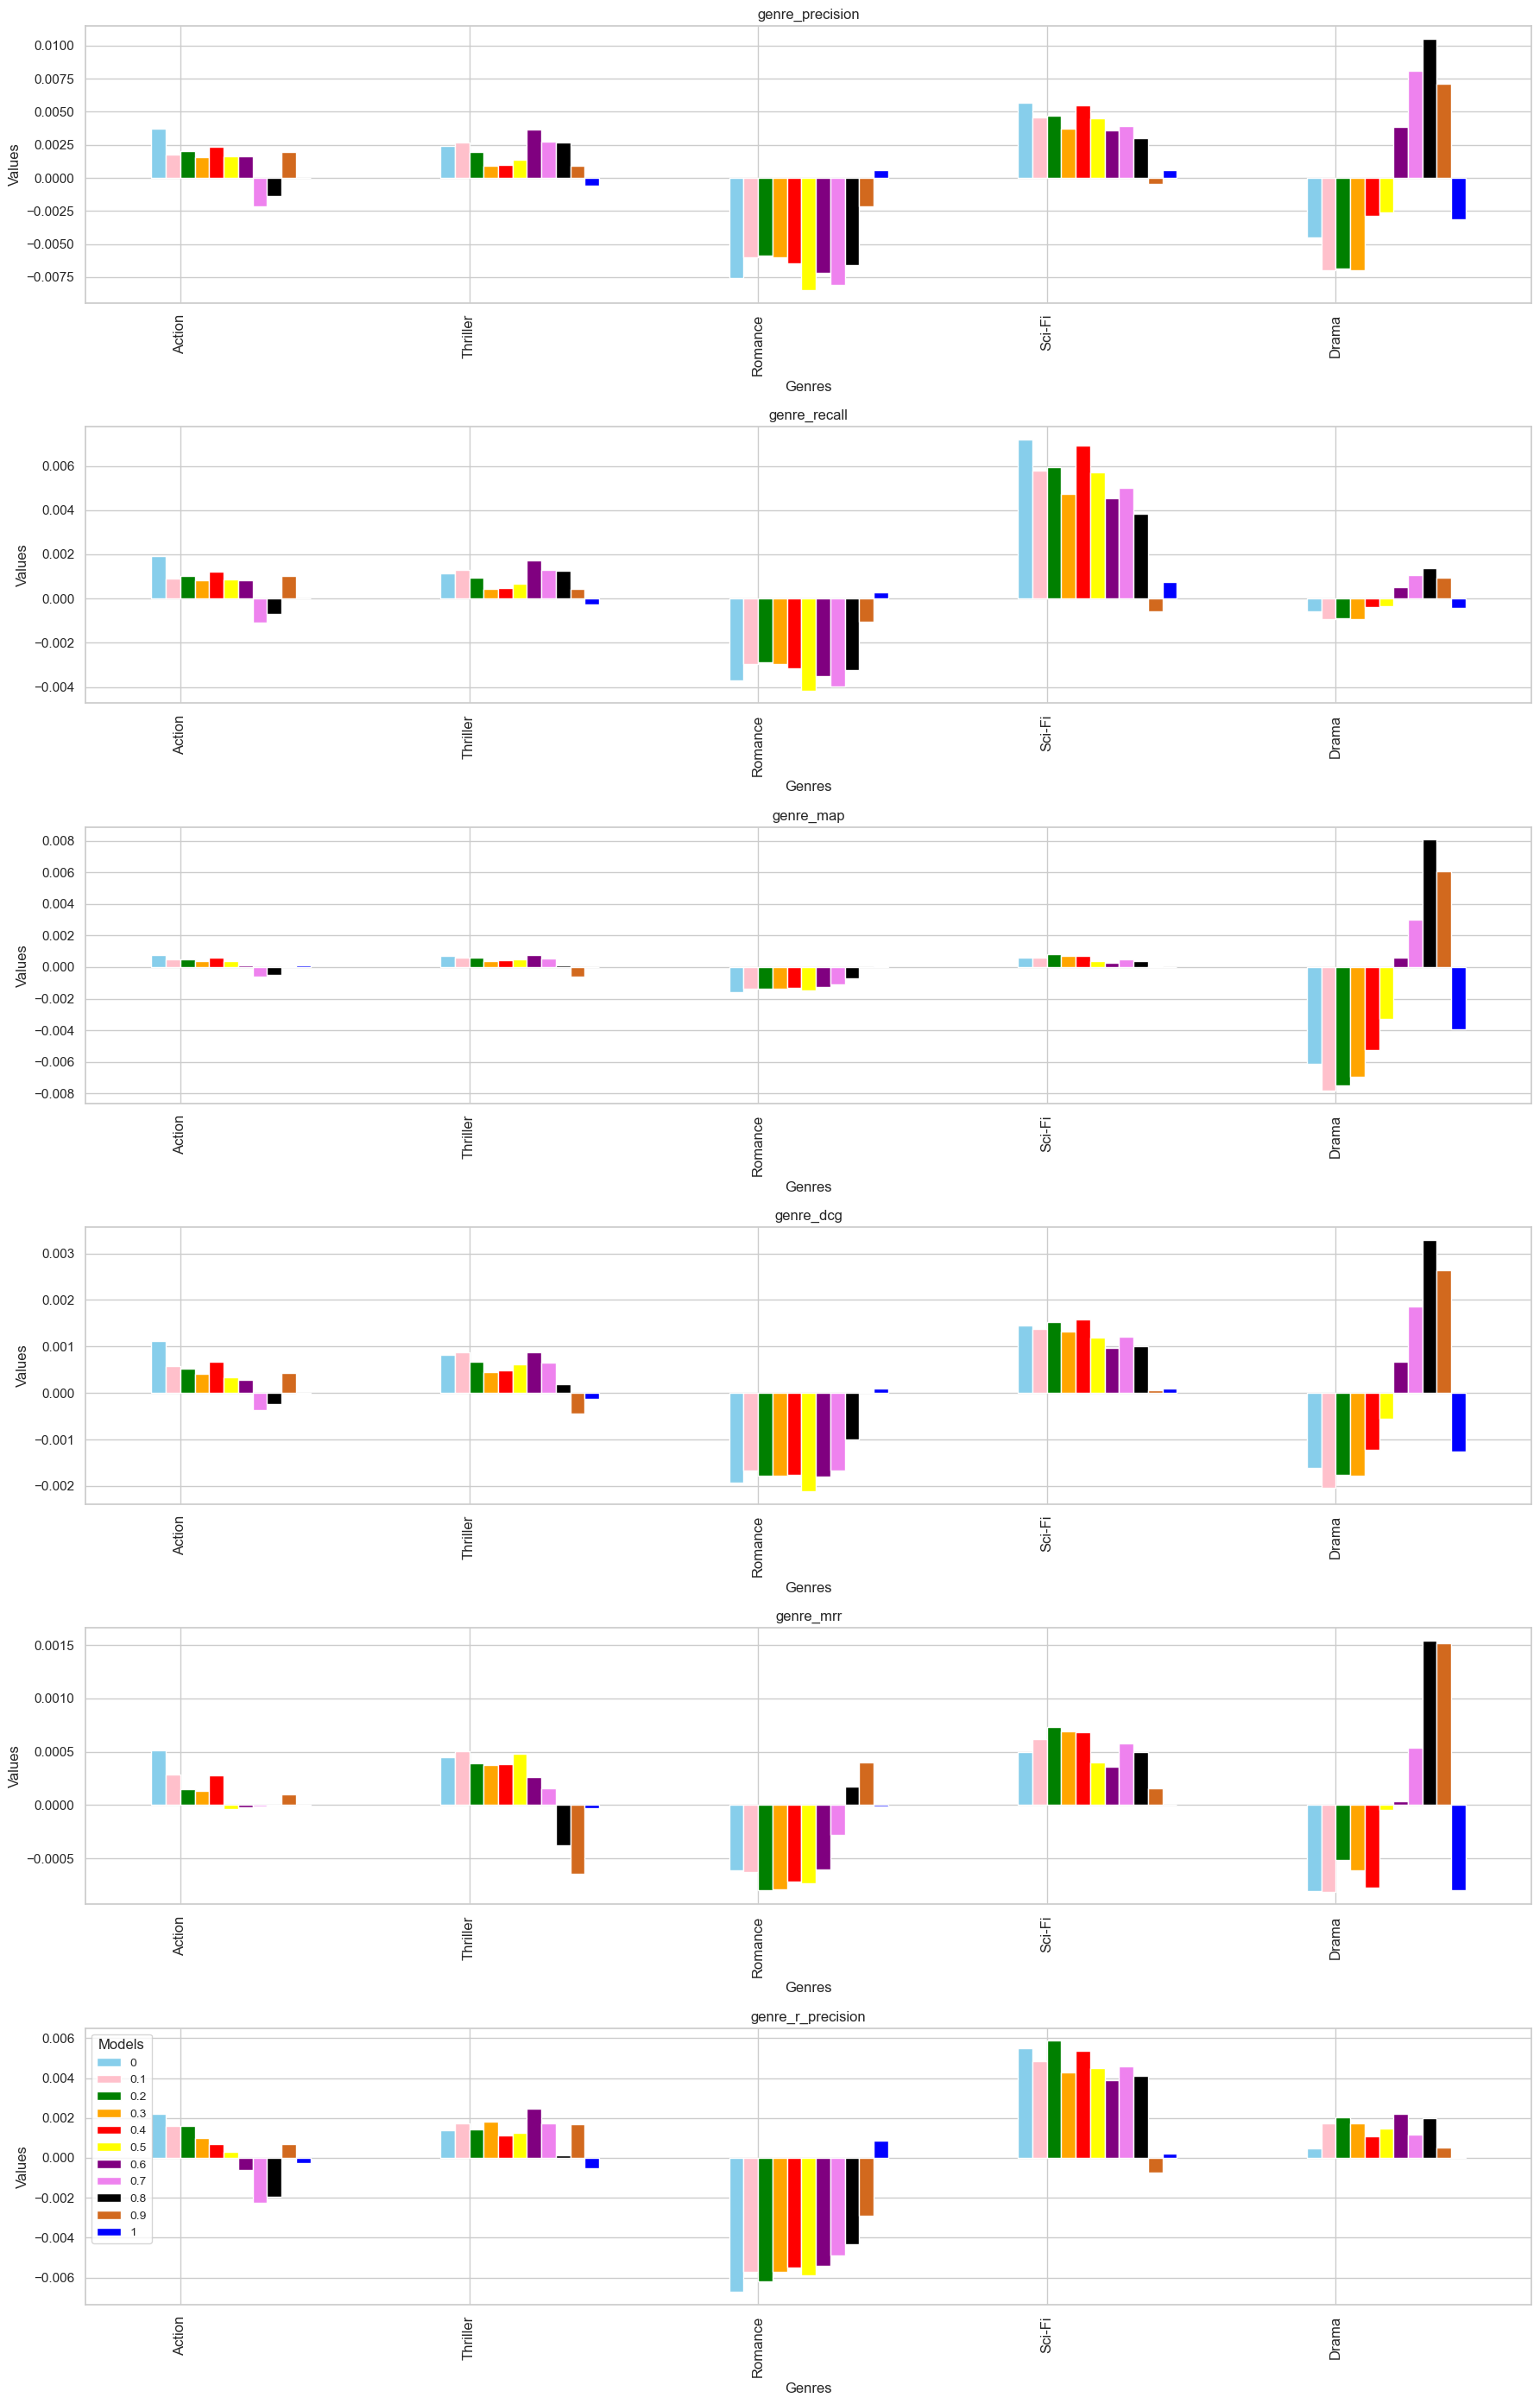

In [45]:

import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]
matrices_6 = [
    model_gps[5][indices],
    model_grs[5][indices],
    model_gms[5][indices],
    model_gdcgs[5][indices],
    model_gmrrs[5][indices],
    model_grps[5][indices],
]
matrices_7 = [
    model_gps[6][indices],
    model_grs[6][indices],
    model_gms[6][indices],
    model_gdcgs[6][indices],
    model_gmrrs[6][indices],
    model_grps[6][indices],
]
matrices_8 = [
    model_gps[7][indices],
    model_grs[7][indices],
    model_gms[7][indices],
    model_gdcgs[7][indices],
    model_gmrrs[7][indices],
    model_grps[7][indices],
]
matrices_9 = [
    model_gps[8][indices],
    model_grs[8][indices],
    model_gms[8][indices],
    model_gdcgs[8][indices],
    model_gmrrs[8][indices],
    model_grps[8][indices],
]
matrices_10 = [
    model_gps[9][indices],
    model_grs[9][indices],
    model_gms[9][indices],
    model_gdcgs[9][indices],
    model_gmrrs[9][indices],
    model_grps[9][indices],
]
matrices_11 = [
    model_gps[10][indices],
    model_grs[10][indices],
    model_gms[10][indices],
    model_gdcgs[10][indices],
    model_gmrrs[10][indices],
    model_grps[10][indices],
]
# matrices_12 = [
#     model_gps[11][indices],
#     model_grs[11][indices],
#     model_gms[11][indices],
#     model_gdcgs[11][indices],
#     model_gmrrs[11][indices],
#     model_grps[11][indices],
# ]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label=alpha_values[0]
    )
    axs[i].bar(
        x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink",label=alpha_values[1]
    )
    axs[i].bar(
        x + 1 * bar_width / 2, matrices_3[i], bar_width, color="green", label=alpha_values[2]
    )
    axs[i].bar(
        x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label=alpha_values[3]
    )
    axs[i].bar(
        x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label=alpha_values[4]
    )
    axs[i].bar(
        x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label=alpha_values[5]
    )
    axs[i].bar(
        x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label=alpha_values[6]
    )
    axs[i].bar(
        x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    )
    axs[i].bar(
        x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    )
    axs[i].bar(
        x + 15 * bar_width / 2,
        matrices_10[i],
        bar_width,
        color="chocolate",
       label=alpha_values[9]
    )
    axs[i].bar(
        x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    )
    # axs[i].bar(
    #     x + 19 * bar_width / 2, matrices_12[i], bar_width, color="blue", label=alpha_values[11]
    # )
    # axs[i].bar(
    #     x + 21 * bar_width / 2, matrices_13[i], bar_width, color="blue", label=alpha_values[12]
    # )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.show()

###################
# a*gender_loss + (1-a)*mseloss
# genderloss * batch_size * 25
###################

['plain', 'a=0.5 with genre reg', 'bp reg']
[<BarContainer object of 5 artists>, <BarContainer object of 5 artists>, <BarContainer object of 5 artists>]


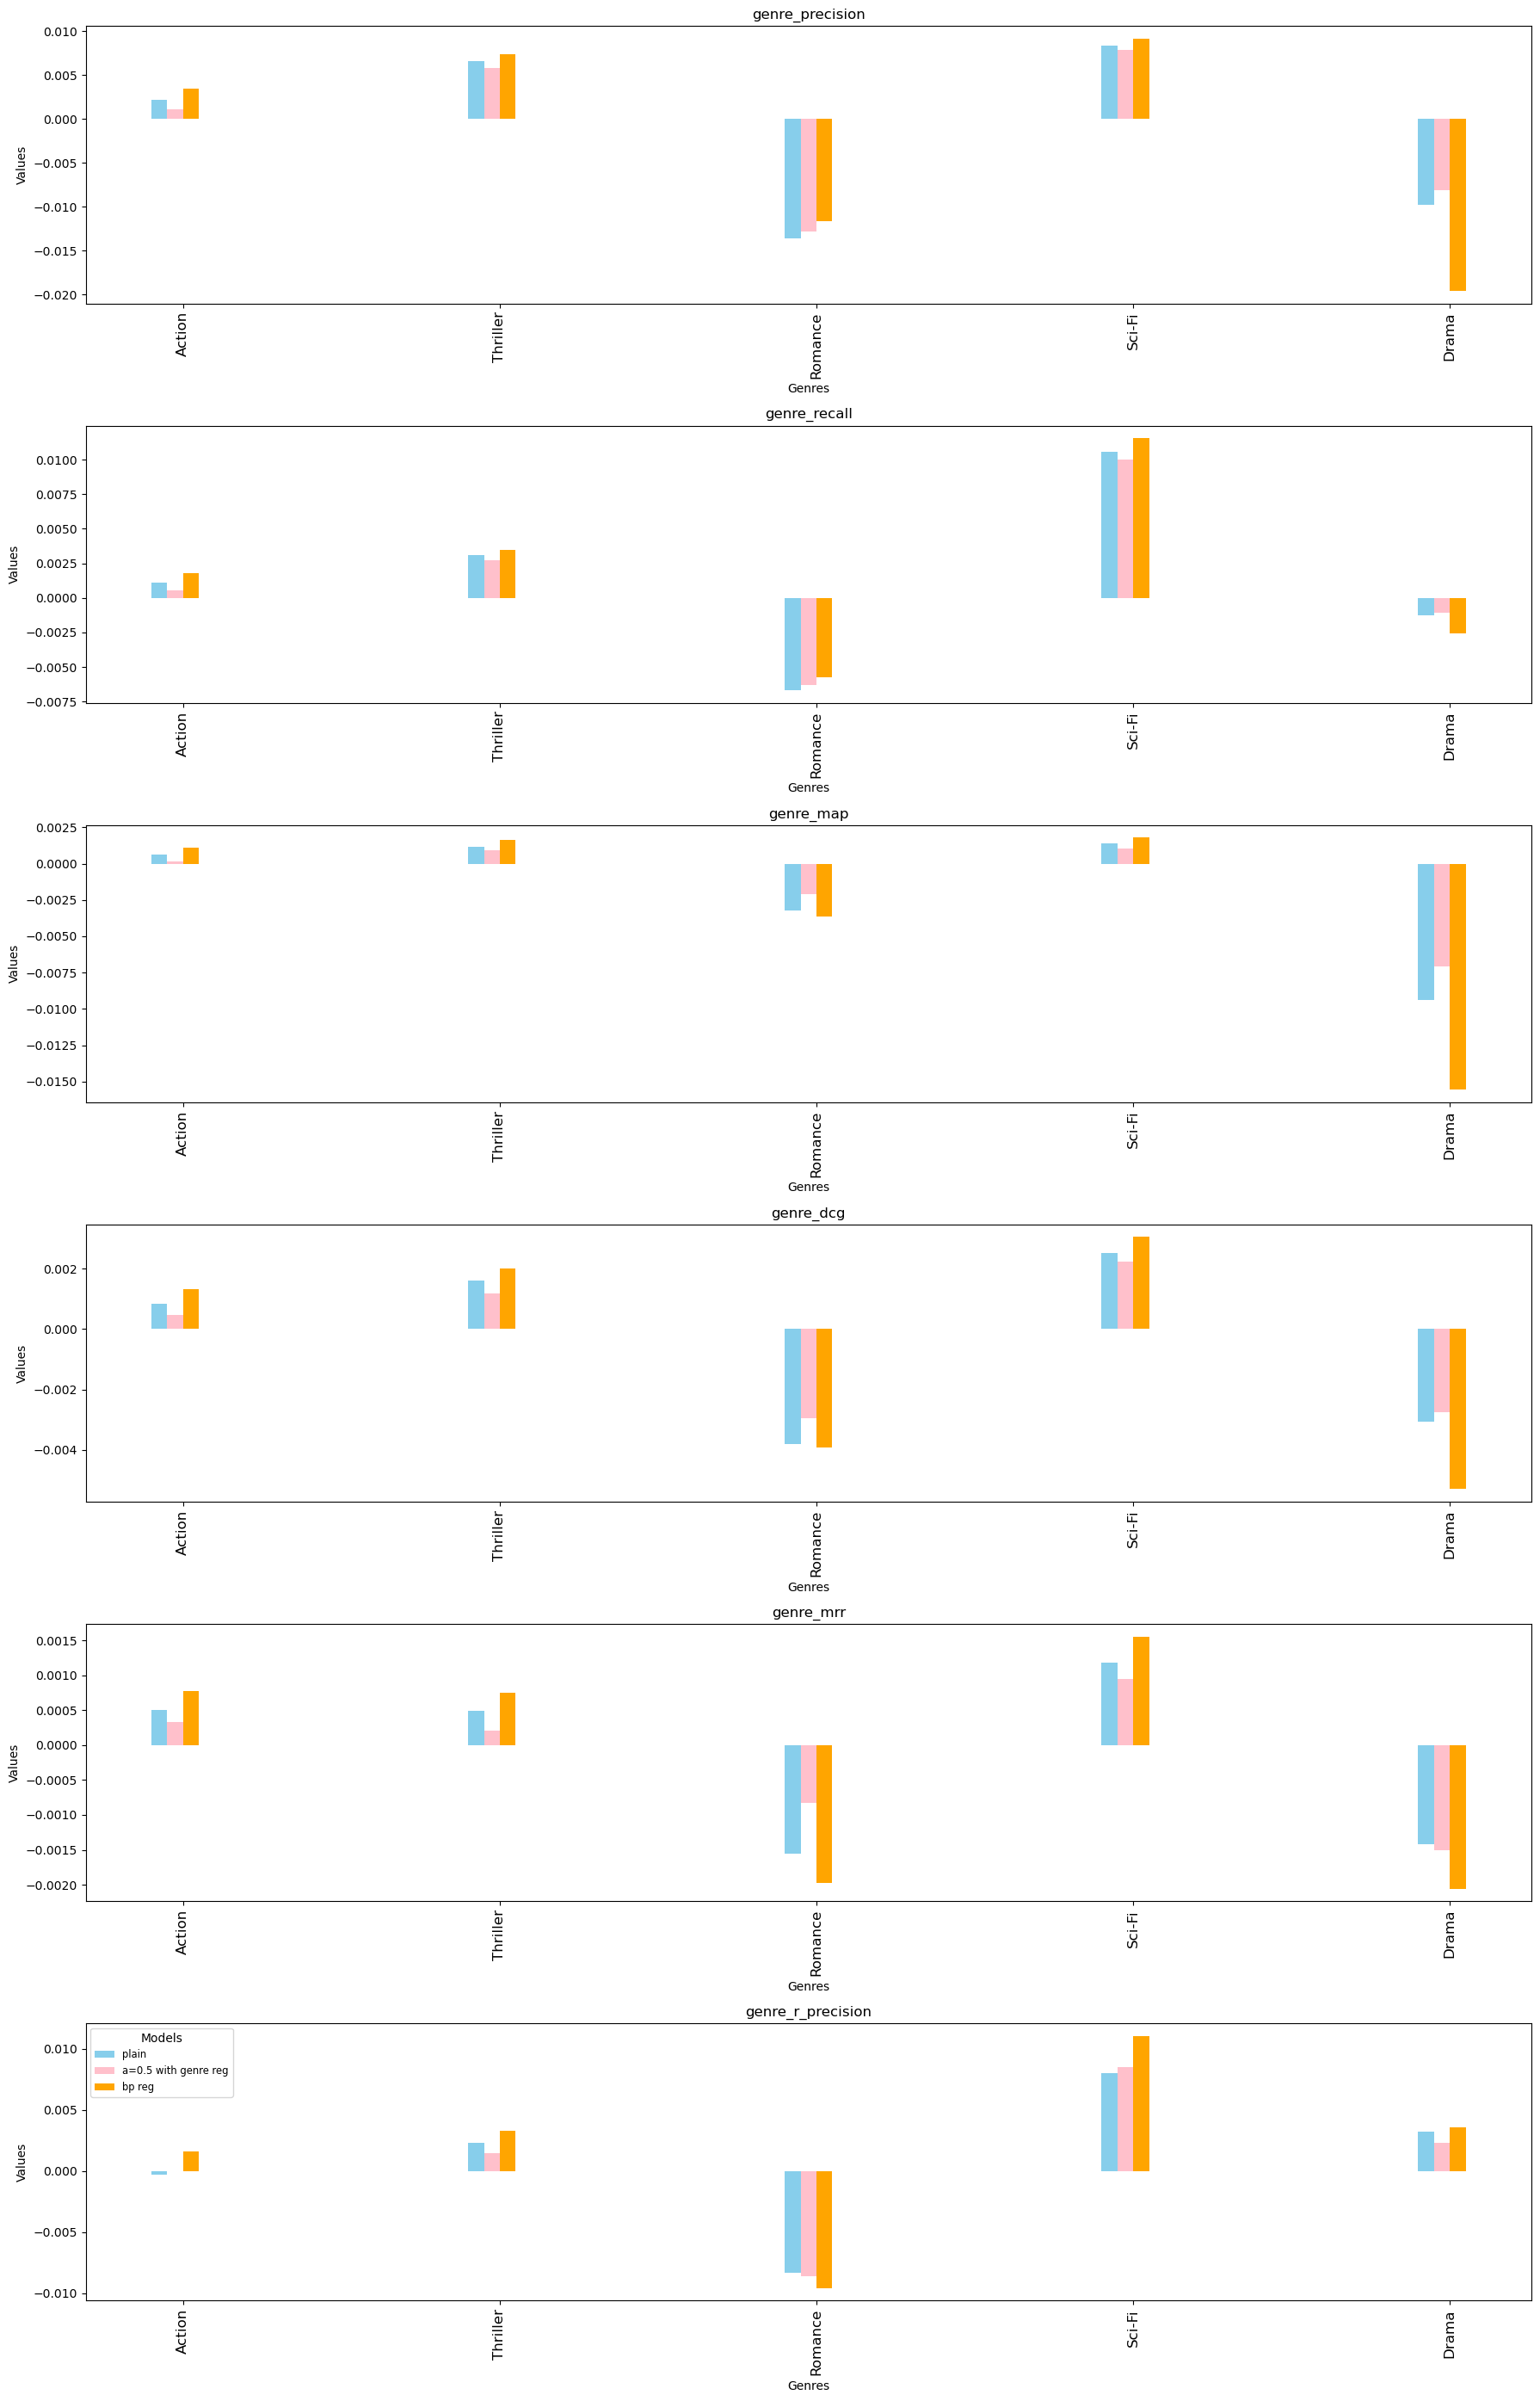

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
# matrices_4 = [
#     model_gps[3][indices],
#     model_grs[3][indices],
#     model_gms[3][indices],
#     model_gdcgs[3][indices],
#     model_gmrrs[3][indices],
#     model_grps[3][indices],
# ]
# matrices_5 = [
#     model_gps[4][indices],
#     model_grs[4][indices],
#     model_gms[4][indices],
#     model_gdcgs[4][indices],
#     model_gmrrs[4][indices],
#     model_grps[4][indices],
# ]
# matrices_6 = [
#     model_gps[5][indices],
#     model_grs[5][indices],
#     model_gms[5][indices],
#     model_gdcgs[5][indices],
#     model_gmrrs[5][indices],
#     model_grps[5][indices],
# ]
# matrices_7 = [
#     model_gps[6][indices],
#     model_grs[6][indices],
#     model_gms[6][indices],
#     model_gdcgs[6][indices],
#     model_gmrrs[6][indices],
#     model_grps[6][indices],
# ]
# matrices_8 = [
#     model_gps[7][indices],
#     model_grs[7][indices],
#     model_gms[7][indices],
#     model_gdcgs[7][indices],
#     model_gmrrs[7][indices],
#     model_grps[7][indices],
# ]
# matrices_9 = [
#     model_gps[8][indices],
#     model_grs[8][indices],
#     model_gms[8][indices],
#     model_gdcgs[8][indices],
#     model_gmrrs[8][indices],
#     model_grps[8][indices],
# ]
# matrices_10 = [
#     model_gps[9][indices],
#     model_grs[9][indices],
#     model_gms[9][indices],
#     model_gdcgs[9][indices],
#     model_gmrrs[9][indices],
#     model_grps[9][indices],
# ]
# matrices_11 = [
#     model_gps[10][indices],
#     model_grs[10][indices],
#     model_gms[10][indices],
#     model_gdcgs[10][indices],
#     model_gmrrs[10][indices],
#     model_grps[10][indices],
# ]
# matrices_12 = [
#     model_gps[11][indices],
#     model_grs[11][indices],
#     model_gms[11][indices],
#     model_gdcgs[11][indices],
#     model_gmrrs[11][indices],
#     model_grps[11][indices],
# ]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label="plain"
    )
    axs[i].bar(
        x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink",label="a=0.5 with genre reg"
    )
    axs[i].bar(
        x +1* bar_width / 2, matrices_3[i], bar_width, color="orange",label="bp reg"
    )
    # axs[i].bar(
    #     x + 1 * bar_width / 2, matrices_3[i], bar_width, color="green", label=alpha_values[2]
    # )
    # axs[i].bar(
    #     x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label=alpha_values[3]
    # )
    # axs[i].bar(
    #     x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label=alpha_values[4]
    # )
    # axs[i].bar(
    #     x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label=alpha_values[5]
    # )
    # axs[i].bar(
    #     x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label=alpha_values[6]
    # )
    # axs[i].bar(
    #     x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    # )
    # axs[i].bar(
    #     x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    # )
    # axs[i].bar(
    #     x + 15 * bar_width / 2,
    #     matrices_10[i],
    #     bar_width,
    #     color="chocolate",
    #    label=alpha_values[9]
    # )
    # axs[i].bar(
    #     x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    # )
    # axs[i].bar(
    #     x + 19 * bar_width / 2, matrices_12[i], bar_width, color="blue", label=alpha_values[11]
    # )
    # axs[i].bar(
    #     x + 21 * bar_width / 2, matrices_13[i], bar_width, color="blue", label=alpha_values[12]
    # )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
model_gdcgs[1]

array([ 4.66469962e-04,  1.19167374e-03, -2.96605077e-03,  1.76456712e-04,
       -5.67295072e-04,  2.91476181e-04, -5.25749675e-05,  9.49979414e-04,
        5.47259173e-05, -2.02776024e-03,  6.78788146e-04,  2.23882879e-03,
        1.58551086e-04,  2.83584774e-03, -1.56498744e-03,  2.71371338e-04,
        6.10603193e-04, -2.74610373e-03])

In [51]:


all_values = [
    ["a=0 mf", 1.0028, 0.5636, 0.0528, 0.6501, 0.0440, 0.1571, 0.0792, 0.0429, 0.1009, 5.9468, 0.6271],
    ["a=0.1 mf", 1.0007, 0.5609, 0.0529, 0.6575, 0.0432, 0.1519, 0.0784, 0.0430, 0.1015, 133.6435, 0.5747],
    ["a=0.2 mf", 0.9963, 0.5596, 0.0530, 0.6554, 0.0435, 0.1534, 0.0789, 0.0431, 0.1014, 131.6855, 0.5737],
    ["a=0.3 mf", 0.9901, 0.5582, 0.0525, 0.6490, 0.0444, 0.1633, 0.0800, 0.0427, 0.1005, 130.1983, 0.5649],
    ["a=0.4 mf", 0.9860, 0.5556, 0.0542, 0.6511, 0.0453, 0.1734, 0.0831, 0.0439, 0.1035, 134.0786, 0.5741],
    ["a=0.5 mf", 0.9841, 0.5531, 0.0542, 0.6394, 0.0452, 0.1683, 0.0825, 0.0440, 0.1036, 148.7229, 0.6262],
    ["a=0.6 mf", 0.9833, 0.5479, 0.0543, 0.6246, 0.0452, 0.1659, 0.0819, 0.0441, 0.1028, 135.8487, 0.5760],
    ["a=0.7 mf", 0.9855, 0.5381, 0.0522, 0.5938, 0.0442, 0.1574, 0.0781, 0.0426, 0.0972, 137.1758, 0.6263],
    ["a=0.8 mf", 0.9974, 0.5237, 0.0498, 0.5758, 0.0424, 0.1607, 0.0747, 0.0407, 0.0923, 135.4480, 0.7201],
    ["a=0.9 mf", 1.0251, 0.4892, 0.0442, 0.5366, 0.0366, 0.1237, 0.0632, 0.0359, 0.0820, 148.9166, 0.6618],
    ["a=1 mf", 1.1464, 0.3459, 0.0118, 0.3033, 0.0159, 0.0428, 0.0150, 0.0106, 0.0179, 126.6729, 0.7206]
]



rmse_values_extracted = [values[0] for values in all_values]
auc_values_extracted = [values[1] for values in all_values]
recall_values_extracted = [values[7] for values in all_values]
hit_ratio_values_extracted = [values[4] for values in all_values]


In [ ]:
rmse_values_extracted

[0.9496,
 0.9487,
 0.9481,
 0.9476,
 0.9477,
 0.9488,
 0.9516,
 0.9573,
 0.968,
 0.99,
 1.129]

In [46]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [49]:
len(gp_sum)

11

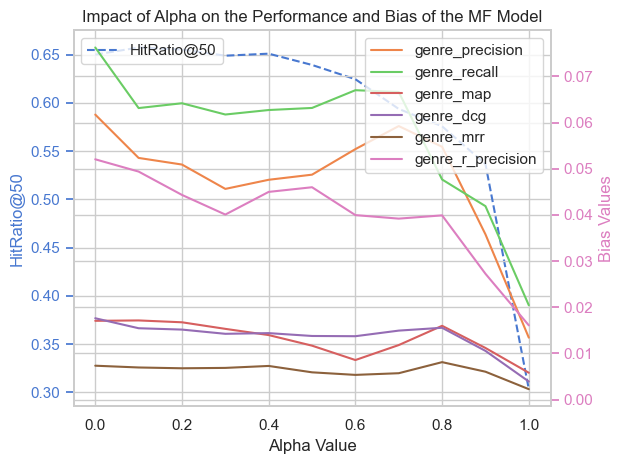

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns


x = alpha_values
upper_bound = len(alpha_values)

sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()

ax1.plot(x[0:upper_bound], hit_ratio_values_extracted[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], linestyle="dotted", color=pastel_palette[0], label="RMSE")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.tight_layout()
plt.show()


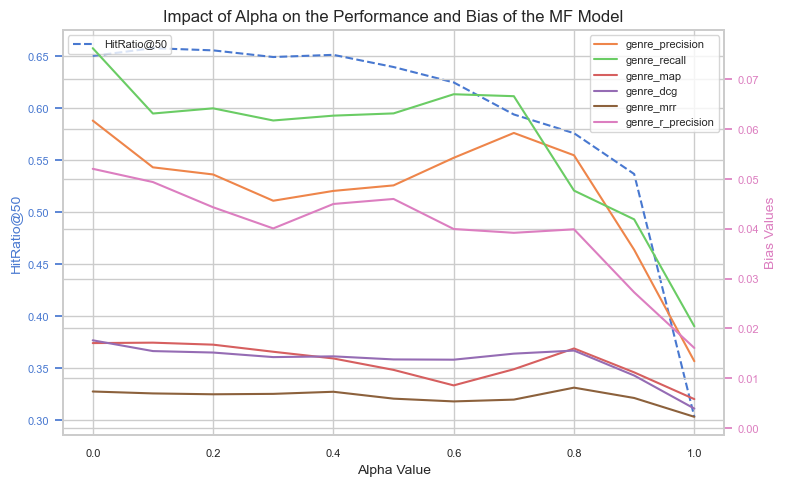

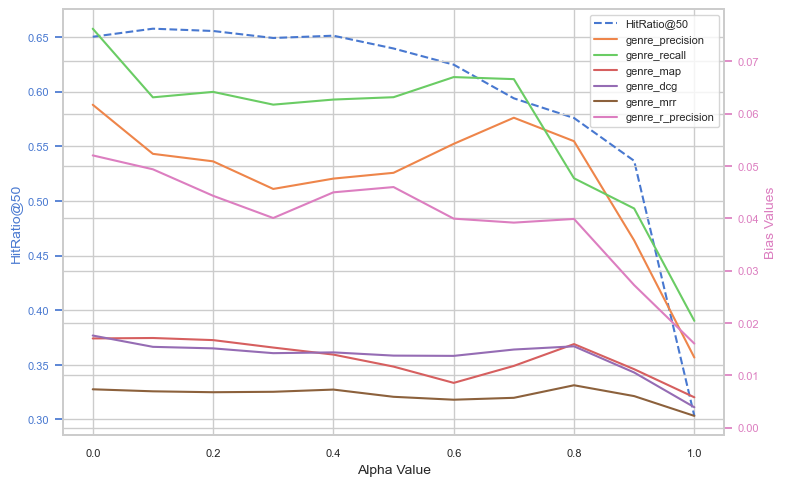

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = len(alpha_values)

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact

# Plot the HitRatio@50
ax1.plot(x[0:upper_bound], hit_ratio_values_extracted[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot

# Show the plotimport matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = len(alpha_values)

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact

# Plot the HitRatio@50
hitratio_line, = ax1.plot(x[0:upper_bound], hit_ratio_values_extracted[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
gp_line, = ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
gr_line, = ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
gm_line, = ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
gdcg_line, = ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
gmrr_line, = ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
grp_line, = ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Combine legends from both axes
lines = [hitratio_line, gp_line, gr_line, gm_line, gdcg_line, gmrr_line, grp_line]
labels = [line.get_label() for line in lines]

# Set a single legend for both ax1 and ax2
ax2.legend(lines, labels, loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
# plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot
plt.savefig("ml_100k_reg.pdf", format="pdf")
# Show the plot
plt.show()

plt.show()


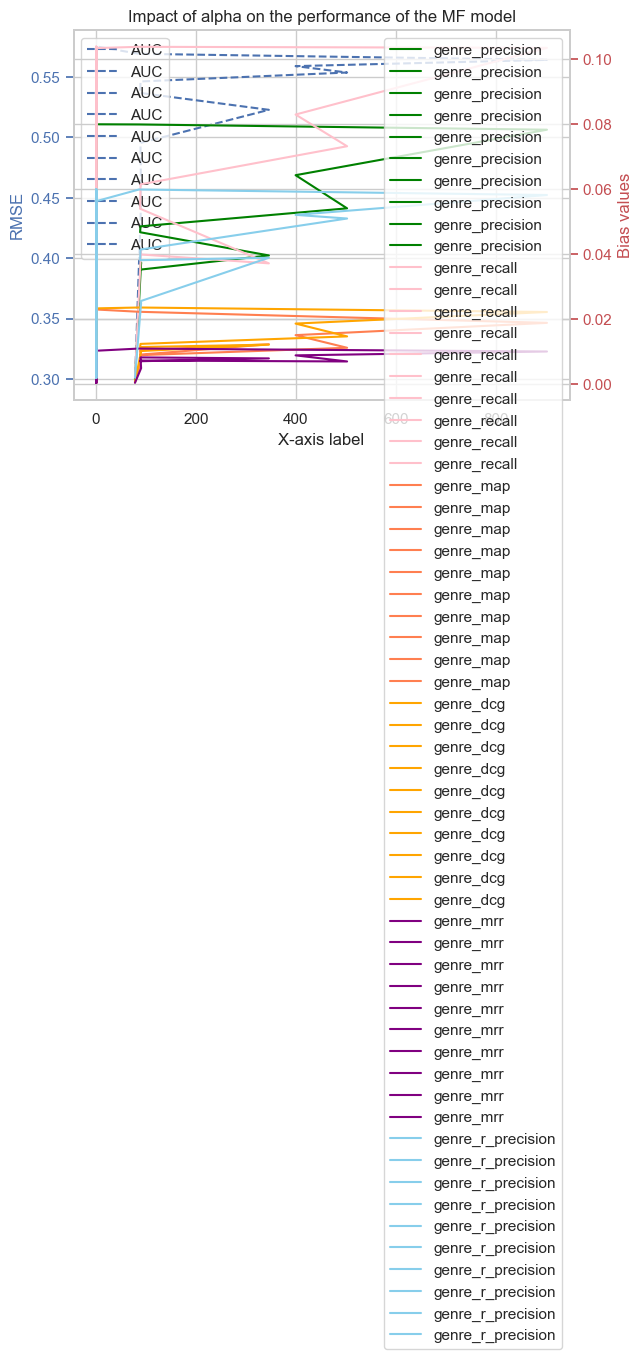

In [ ]:
import matplotlib.pyplot as plt

# Sample data
x = alpha_values


# Data for the primary y-axis
# Data for the secondary y-axis

# Create a figure and a set of subplots
fig, ax1 = plt.subplots()
upper_bound=13
# Plot data on the primary y-axis
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound],color= "skyblue", label="AUC")
ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], "b--", label="AUC")
ax1.set_xlabel("X-axis label")
ax1.set_ylabel("RMSE", color="b")
ax1.tick_params("y", colors="b")

# Create a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color="green")
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color="pink")
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color="coral")
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color="orange")
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color="purple")
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color="skyblue")
ax2.set_ylabel("Bias values", color="r")
ax2.tick_params("y", colors="r")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Show the plot
plt.title("Impact of alpha on the performance of the MF model")
plt.show()

In [ ]:
top_k = 20
reco_matrix_n = np.zeros((len(user_ids), top_k), dtype=int)

for i in range(reco_matrix[0].shape[0]):
    reco_matrix_n[i] = reco_matrix[1][i][:top_k]

reco_matrix_n.shape

In [ ]:
reco_matrix[1].shape[0]
# top_k = 50
# reco_matrix = np.zeros((reco_matrix_all_items.shape[0], top_k), dtype=int)
# for i in range(reco_matrix_all_items.shape[0]):
#     reco_matrix[i] = reco_matrix_all_items[i][:top_k]

In [ ]:
sum(model_gdcg_2)

In [ ]:
# np.where(reco_matrix_mapped_items[1][0]==0)
# reco_matrix_all[1][0][258]
reco_matrix_mapped_scores[1][1][1552]

# reco_matrix_mapped_items[1][1][1552]
# reco_matrix_mapped_items[1][0][258]
# reco_items_scores_all[0]
# mapped_item_index

In [ ]:
reco_items_scores_all[0][0]
# np.save("reco_items_scores_all.npy",reco_items_scores_all)

In [ ]:
# unique_genres = ['Crime',
#  'Film-Noir',
#  'Adventure',
#  'Fantasy',
#  'Sci-Fi',
#  'Documentary',
#  'Drama',
#  'Horror',
#  'War',
#  'Animation',
#  'Romance',
#  "Children's",
#  'Western',
#  'Mystery',
#  'Thriller',
#  'Musical',
#  'Action',
#  'Comedy']

In [ ]:
# tahsin kheya
# last modified 21/07/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger
import random


class Calibration(object):
    def __init__(self, config, movies, top_k, unique_genres, users):
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(self.device)
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []

        # self.logger = getLogger()
        self.top_k = top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.unique_genres = list(self.actual_genre_dist.columns)[1:]

        # self.actual_genre_dist = self.actual_genre_dist.drop(columns=["userID"])

        self.config = config
        self.item_df = movies
        self.actual_distribution_without_id = self.actual_genre_dist.drop(
            columns=["userID"]
        ).to_numpy()
        print(self.unique_genres)
        # print(self.actual_distribution_without_id)

        self.actual_distribution_gender = []

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(topk_reco.shape[0]), self.top_k),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(np.arange(1, self.top_k + 1), topk_reco.shape[0]),
            }
        )

        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[self.unique_genres].div(
            merged_df[self.unique_genres].sum(axis=1), axis=0
        )

        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None] * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        #         reco_distribution[self.unique_genres] = reco_distribution[
        #             self.unique_genres
        #         ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution

    def get_recom_distribution(self, reco):

        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))

        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        #         print(item_genre_weights)
        # Normalize genre weights so sum is 1
        #         item_genre_weights /= torch.sum(item_genre_weights, axis=1, keepdims=True)

        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)

        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    # def get_gender_representation_one_user(self, reco_dist, uid):
    #     c = []
    #     retVal = []
    #     print(self.actual_distribution[uid])

    #     for i in range(len(self.unique_genres)):
    #         c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
    #     # Assuming self.unique_genres is a list or array-like
    #     genre_columns_count = len(self.unique_genres)

    #     reco_dist_slice = reco_dist[:genre_columns_count]
    #     actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

    #     log_ratios = np.log(reco_dist_slice / actual_dist_slice)
    #     retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
        #
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])
        # print(f"reco item {reco_items}, genre_dist_actual_user {self.actual_distribution_without_id[uid]}, reco genre distribution {reco_dist}")
        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution_without_id[uid], alpha, uid
        )

        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids = self.gender_df[self.gender_df["Gender"] == 0]["userID"]
        male_user_ids = male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        # gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)
        gender_kl = 0

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[reco_items[r]]

        # print(f"genderkl {gender_kl}, kl {kl} score{sum_score}")

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")
        # print(f"score {sum_score}, kl {kl}, gender_kl {gender_kl}")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl

    # c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items, items, scores):

        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(
            reco=top_items, scores=scores, all_items=items
        )

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(
            self.actual_genre_dist, self.gender_df, on="userID"
        )
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores, all_items):
        """reco is 6040x50 and scores is 6040x3416"""

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        #####
        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        b = 0.69  # beta
        l = 0.29  # lambda
        all_users = []

        #####

        top_k = self.top_k

        n_users, n_items = all_items.shape

        for u in range(0, 50):
            # remaining_items = all_items
            remaining_items = list(all_items[u])
            # print(remaining_items)

            #             u_calibrated = [623, 1612, 558, 1087, 1347, 3368, 196, 3256, 3127, 882, 831, 1271, 1870, 2594, 3279, 2624, 393, 1496, 3099, 2414, 1232, 1773, 1313, 610, 500, 2855, 1973, 1872, 3334, 3296, 649, 769, 1573, 2474, 2133, 2161, 3387, 2640, 1583, 3287, 753, 384, 2192, 709, 1981, 3311 ]
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores[u], user_reco_dist, b
                    )
                    for i in remaining_items
                ]
                max_index = np.argmax(diversity_scores)

                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)

In [ ]:
reco_matrix_all[1].shape

In [ ]:
score_dicts[1][889]
reco_matrix_all[1][0][0]
score_dicts[1][0]

In [ ]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file": "./cornac/data_c/user_genre_dist_new.csv"}
c = Calibration(
    config=config, movies=movies, top_k=50, unique_genres=unique_genres, users=users
)
# for itemknn

reranked_reco = c.get_improved_reco(reco_matrix[1], reco_matrix_all[1], score_dicts)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)

    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if movies.at[index, genre] == 1:
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd, movies, how="inner", on="itemID")
mergde_pd

In [ ]:
user_genre_means = mergde_pd.groupby("userID")[unique_genres].mean()
user_genre_means

In [ ]:
users

In [ ]:
useer = pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z = inter_movies[["userID", "itemID", "Gender"]]
mergz = pd.merge(z, movies, on="itemID", how="left")
mergz
user_genre_gender = mergz.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="feMale (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="female (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# inter_movies["itemID"].nunique()
reco_matrix_new.shape

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix_new.shape[0] + 1).repeat(reco_matrix_new.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix_new.flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv("biased_movie_lens.csv")

In [ ]:
movies_df

In [ ]:

np.save('reco_matrix.npy', reco_matrix)
np.save('reco_matrix_mapped_items.npy', reco_matrix_mapped_items)
np.save('reco_matrix_mapped_scores.npy', reco_matrix_mapped_scores)
np.save('reco_matrix_all.npy', reco_matrix_all)np.save('reco_items_scores_all.npy' , reco_matrix_all_edited)

#reco_matrix_all_items

In [ ]:
import torch

In [ ]:
t = torch.tensor([[0.2500, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.2500, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000, 0.2500],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000],
        [0.2500, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.2500],
        [0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.3333, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.3333, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000,
         0.2500, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000, 0.2500],
        [0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])

In [ ]:
x=t[..., 1].sum()

In [ ]:
x

tensor(6.1665)

In [1]:
model_gps[0]

NameError: name 'model_gps' is not defined